# Data Processing

In [1]:
DATA_DIR = "../data"
DATASET_DIR = f"{DATA_DIR}/processed/csecicids2018"

In [2]:
import pandas as pd
import pprint as pp


pd.set_option('display.max_columns', None)

In [3]:
pd

<module 'pandas' from '/usr/local/lib/python3.10/dist-packages/pandas/__init__.py'>

## Convert the Dataset from Multi-Label to Binary Classification

In [4]:
# df_multilabel = pd.read_parquet(f"{DATA_DIR}/processed/csecicids2018.parquet")
df_multilabel = pd.read_parquet("/kaggle/input/cicids/cse-binary.parquet")
df_multilabel.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Avg Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init Fwd Win Bytes,Init Bwd Win Bytes,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,141385,9,7,553,3773.0,202,0,61.444443,87.534439,1460,0,539.000000,655.432922,30597.30523,113.166178,9425.666992,19069.117188,73403.0,1.0,141385.0,17673.125000,23965.324219,73403.0,22.0,51417.0,8569.500000,13036.890625,31525.0,1.0,0,0,0,0,192,152,63.655975,49.510204,0,1460,254.470581,474.712952,225352.390625,0,0,1,1,0,0,0,1,0,270.375000,61.444443,539.000000,0,0,0,0,0,0,9,553,7,3773,8192,119,4,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,6,281,2,1,38,0.0,38,0,19.000000,26.870058,0,0,0.000000,0.000000,135231.31670,10676.156580,140.500000,174.655380,264.0,17.0,281.0,281.000000,0.000000,281.0,281.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,40,20,7117.437500,3558.718750,0,38,19.000000,21.939310,481.333344,0,1,0,0,1,0,0,0,0,25.333334,19.000000,0.000000,0,0,0,0,0,0,2,38,1,0,123,0,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,6,279824,11,15,1086,10527.0,385,0,98.727272,129.392502,1460,0,701.799988,636.314209,41501.08640,92.915547,11192.959961,24379.449219,112589.0,1.0,279728.0,27972.800781,36167.742188,112589.0,94.0,258924.0,18494.572266,36356.503906,133669.0,1.0,0,0,0,0,232,312,39.310425,53.605122,0,1460,430.111115,566.234192,320621.187500,0,0,1,1,0,0,0,1,1,446.653839,98.727272,701.799988,0,0,0,0,0,0,11,1086,15,10527,8192,1047,5,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,6,132,2,0,0,0.0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.00000,15151.515150,132.000000,0.000000,132.0,132.0,132.0,132.000000,0.000000,132.0,132.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0,0,40,0,15151.515625,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,2,0,0,0,256,-1,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,6,274016,9,13,1285,6141.0,517,0,142.777771,183.887726,1460,0,472.384613,611.180481,27100.60726,80.287282,13048.380859,26311.626953,114077.0,1.0,273946.0,34243.250000,37996.566406,114077.0,201.0,252994.0,21082.833984,39075.738281,135611.0,1.0,0,0,0,0,192,272,32.844799,47.442486,0,1460,322.869568,497.254761,247262.296875,0,0,1,1,0,0,0,1,1,337.545441,142.777771,472.384613,0,0,0,0,0,0,9,1285,13,6141,8192,1047,5,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [5]:
# df = pd.read_parquet(f"{DATA_DIR}/processed/cse-binary.parquet")
df = pd.read_parquet("/kaggle/input/cicids/cse-binary.parquet")
df.head(5)

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Avg Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init Fwd Win Bytes,Init Bwd Win Bytes,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,141385,9,7,553,3773.0,202,0,61.444443,87.534439,1460,0,539.000000,655.432922,30597.30523,113.166178,9425.666992,19069.117188,73403.0,1.0,141385.0,17673.125000,23965.324219,73403.0,22.0,51417.0,8569.500000,13036.890625,31525.0,1.0,0,0,0,0,192,152,63.655975,49.510204,0,1460,254.470581,474.712952,225352.390625,0,0,1,1,0,0,0,1,0,270.375000,61.444443,539.000000,0,0,0,0,0,0,9,553,7,3773,8192,119,4,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,6,281,2,1,38,0.0,38,0,19.000000,26.870058,0,0,0.000000,0.000000,135231.31670,10676.156580,140.500000,174.655380,264.0,17.0,281.0,281.000000,0.000000,281.0,281.0,0.0,0.000000,0.000000,0.0,0.0,1,0,0,0,40,20,7117.437500,3558.718750,0,38,19.000000,21.939310,481.333344,0,1,0,0,1,0,0,0,0,25.333334,19.000000,0.000000,0,0,0,0,0,0,2,38,1,0,123,0,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,6,279824,11,15,1086,10527.0,385,0,98.727272,129.392502,1460,0,701.799988,636.314209,41501.08640,92.915547,11192.959961,24379.449219,112589.0,1.0,279728.0,27972.800781,36167.742188,112589.0,94.0,258924.0,18494.572266,36356.503906,133669.0,1.0,0,0,0,0,232,312,39.310425,53.605122,0,1460,430.111115,566.234192,320621.187500,0,0,1,1,0,0,0,1,1,446.653839,98.727272,701.799988,0,0,0,0,0,0,11,1086,15,10527,8192,1047,5,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,6,132,2,0,0,0.0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.00000,15151.515150,132.000000,0.000000,132.0,132.0,132.0,132.000000,0.000000,132.0,132.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0,0,40,0,15151.515625,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,2,0,0,0,256,-1,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,6,274016,9,13,1285,6141.0,517,0,142.777771,183.887726,1460,0,472.384613,611.180481,27100.60726,80.287282,13048.380859,26311.626953,114077.0,1.0,273946.0,34243.250000,37996.566406,114077.0,201.0,252994.0,21082.833984,39075.738281,135611.0,1.0,0,0,0,0,192,272,32.844799,47.442486,0,1460,322.869568,497.254761,247262.296875,0,0,1,1,0,0,0,1,1,337.545441,142.777771,472.384613,0,0,0,0,0,0,9,1285,13,6141,8192,1047,5,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [6]:
df.shape

(6659532, 78)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6659532 entries, 0 to 6659531
Data columns (total 78 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Protocol                  int8   
 1   Flow Duration             int64  
 2   Total Fwd Packets         int32  
 3   Total Backward Packets    int32  
 4   Fwd Packets Length Total  int32  
 5   Bwd Packets Length Total  float64
 6   Fwd Packet Length Max     int32  
 7   Fwd Packet Length Min     int16  
 8   Fwd Packet Length Mean    float32
 9   Fwd Packet Length Std     float32
 10  Bwd Packet Length Max     int32  
 11  Bwd Packet Length Min     int16  
 12  Bwd Packet Length Mean    float32
 13  Bwd Packet Length Std     float32
 14  Flow Bytes/s              float64
 15  Flow Packets/s            float64
 16  Flow IAT Mean             float32
 17  Flow IAT Std              float32
 18  Flow IAT Max              float64
 19  Flow IAT Min              float64
 20  Fwd IAT Total           

## Select KBest Features

In [8]:
X = df.drop(columns=["Label"])
y = df["Label"]

In [9]:
X.shape, y.shape

((6659532, 77), (6659532,))

In [10]:
# remove columns with only one unique value
X = X.loc[:, X.nunique() != 1]

X.shape

(6659532, 69)

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif


def select_k_best_features(X, y, k=10):
    selector = SelectKBest(score_func=f_classif, k=k)
    X_new = selector.fit_transform(X, y)
    mask = selector.get_support()
    selected_features = X.columns[mask]
    return selected_features


selected_features = select_k_best_features(X, y, k=64)

selected_features.shape


(64,)

In [12]:
# list of selected features
selected_features



Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Std',
       'Fwd IAT Max', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags',
       'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s',
       'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max',
       'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
       'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count',
       'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count',
     

In [13]:
# list unselected features
unselected_features = X.columns.difference(selected_features)
unselected_features

Index(['Flow IAT Mean', 'Flow IAT Min', 'Fwd IAT Mean', 'Fwd IAT Min',
       'Idle Std'],
      dtype='object')

In [14]:
X_selected_features = X[selected_features]


X_selected_features.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Std,Flow IAT Max,Fwd IAT Total,Fwd IAT Std,Fwd IAT Max,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Avg Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init Fwd Win Bytes,Init Bwd Win Bytes,Fwd Act Data Packets,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Max,Idle Min
0,6,141385,9,7,553,3773.0,202,0,61.444443,87.534439,1460,0,539.000000,655.432922,30597.30523,113.166178,19069.117188,73403.0,141385.0,23965.324219,73403.0,51417.0,8569.500000,13036.890625,31525.0,1.0,0,0,192,152,63.655975,49.510204,0,1460,254.470581,474.712952,225352.390625,0,0,1,1,0,0,0,1,0,270.375000,61.444443,539.000000,9,553,7,3773,8192,119,4,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,6,281,2,1,38,0.0,38,0,19.000000,26.870058,0,0,0.000000,0.000000,135231.31670,10676.156580,174.655380,264.0,281.0,0.000000,281.0,0.0,0.000000,0.000000,0.0,0.0,1,0,40,20,7117.437500,3558.718750,0,38,19.000000,21.939310,481.333344,0,1,0,0,1,0,0,0,0,25.333334,19.000000,0.000000,2,38,1,0,123,0,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,279824,11,15,1086,10527.0,385,0,98.727272,129.392502,1460,0,701.799988,636.314209,41501.08640,92.915547,24379.449219,112589.0,279728.0,36167.742188,112589.0,258924.0,18494.572266,36356.503906,133669.0,1.0,0,0,232,312,39.310425,53.605122,0,1460,430.111115,566.234192,320621.187500,0,0,1,1,0,0,0,1,1,446.653839,98.727272,701.799988,11,1086,15,10527,8192,1047,5,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,6,132,2,0,0,0.0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.00000,15151.515150,0.000000,132.0,132.0,0.000000,132.0,0.0,0.000000,0.000000,0.0,0.0,0,0,40,0,15151.515625,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,0.000000,0.000000,0.000000,2,0,0,0,256,-1,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,6,274016,9,13,1285,6141.0,517,0,142.777771,183.887726,1460,0,472.384613,611.180481,27100.60726,80.287282,26311.626953,114077.0,273946.0,37996.566406,114077.0,252994.0,21082.833984,39075.738281,135611.0,1.0,0,0,192,272,32.844799,47.442486,0,1460,322.869568,497.254761,247262.296875,0,0,1,1,0,0,0,1,1,337.545441,142.777771,472.384613,9,1285,13,6141,8192,1047,5,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
X_selected_features.shape

(6659532, 64)

## Encoding fields

In [16]:
# get dtype and unique values of each column -> print
for column in X_selected_features.columns:

    pp.pprint(
        {
            "column": column,
            "dtype": X_selected_features[column].dtype,
            "unique_values": X_selected_features[column].nunique(),
        }
    )


{'column': 'Protocol', 'dtype': dtype('int8'), 'unique_values': 3}
{'column': 'Flow Duration', 'dtype': dtype('int64'), 'unique_values': 3161639}
{'column': 'Total Fwd Packets', 'dtype': dtype('int32'), 'unique_values': 4565}
{'column': 'Total Backward Packets',
 'dtype': dtype('int32'),
 'unique_values': 2968}
{'column': 'Fwd Packets Length Total',
 'dtype': dtype('int32'),
 'unique_values': 16899}
{'column': 'Bwd Packets Length Total',
 'dtype': dtype('float64'),
 'unique_values': 64903}
{'column': 'Fwd Packet Length Max',
 'dtype': dtype('int32'),
 'unique_values': 1498}
{'column': 'Fwd Packet Length Min',
 'dtype': dtype('int16'),
 'unique_values': 410}
{'column': 'Fwd Packet Length Mean',
 'dtype': dtype('float32'),
 'unique_values': 68675}
{'column': 'Fwd Packet Length Std',
 'dtype': dtype('float32'),
 'unique_values': 172590}
{'column': 'Bwd Packet Length Max',
 'dtype': dtype('int32'),
 'unique_values': 1462}
{'column': 'Bwd Packet Length Min',
 'dtype': dtype('int16'),
 'uniq

In [17]:
# print all column names
X_selected_features.columns

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Std',
       'Fwd IAT Max', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags',
       'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s',
       'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max',
       'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
       'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count',
       'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count',
     

### One Hot Encoding
For features with a small set of unique values, we can use one hot encoding to convert them into binary values.


In [18]:
# list all columns with more than 2 but less than 100 unique values
onehot_features = X_selected_features.columns[X_selected_features.nunique().between(3, 100)] 
onehot_features

Index(['Protocol', 'Fwd Seg Size Min'], dtype='object')

In [19]:
for column in onehot_features:
    print(f"{column}: {X_selected_features[column].unique()}")
    print(f"{column}: {X_selected_features[column].nunique()}")
    print(f"{column}: {X_selected_features[column].value_counts()}")
    print("\n")

Protocol: [ 6  0 17]
Protocol: 3
Protocol: Protocol
6     5195216
17    1364000
0      100316
Name: count, dtype: int64


Fwd Seg Size Min: [20  0  8 32 28 40 24 44 36 48 56]
Fwd Seg Size Min: 11
Fwd Seg Size Min: Fwd Seg Size Min
20    4409716
8     1364000
32     751977
0      100316
40      13870
28      13426
24       5300
36        810
44        109
48          7
56          1
Name: count, dtype: int64




In [20]:
from sklearn.preprocessing import OneHotEncoder

# drop set to None for SNN; test with first as well
onehot_encoder = OneHotEncoder(drop=None, sparse_output=False)

X_onehot = onehot_encoder.fit_transform(X_selected_features[onehot_features])

print(X_onehot.shape)

# convert to dataframe
X_onehot_df = pd.DataFrame(X_onehot, columns=onehot_encoder.get_feature_names_out(onehot_features))

(6659532, 14)


In [21]:
X_onehot_df.head()

,Protocol_0,Protocol_6,Protocol_17,Fwd Seg Size Min_0,Fwd Seg Size Min_8,Fwd Seg Size Min_20,Fwd Seg Size Min_24,Fwd Seg Size Min_28,Fwd Seg Size Min_32,Fwd Seg Size Min_36,Fwd Seg Size Min_40,Fwd Seg Size Min_44,Fwd Seg Size Min_48,Fwd Seg Size Min_56
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Binary Encoding
For integer value fields with a moderate range of values, encode them into binary values.

In [22]:
# plot a graph of the number of unique values for each column and get a sense of the distribution
# get median, mean, mode, and standard deviation of the number of unique values
import matplotlib.pyplot as plt

unique_values = X_selected_features.nunique()
unique_values.describe()



count    6.400000e+01
mean     6.834598e+05
std      1.155333e+06
min      2.000000e+00
25%      1.199000e+03
50%      6.678900e+04
75%      5.783158e+05
max      3.926087e+06
dtype: float64

In [23]:
# get min and max unique values
min_unique_values = unique_values.min()
max_unique_values = unique_values.max()

min_unique_values, max_unique_values

(2, 3926087)

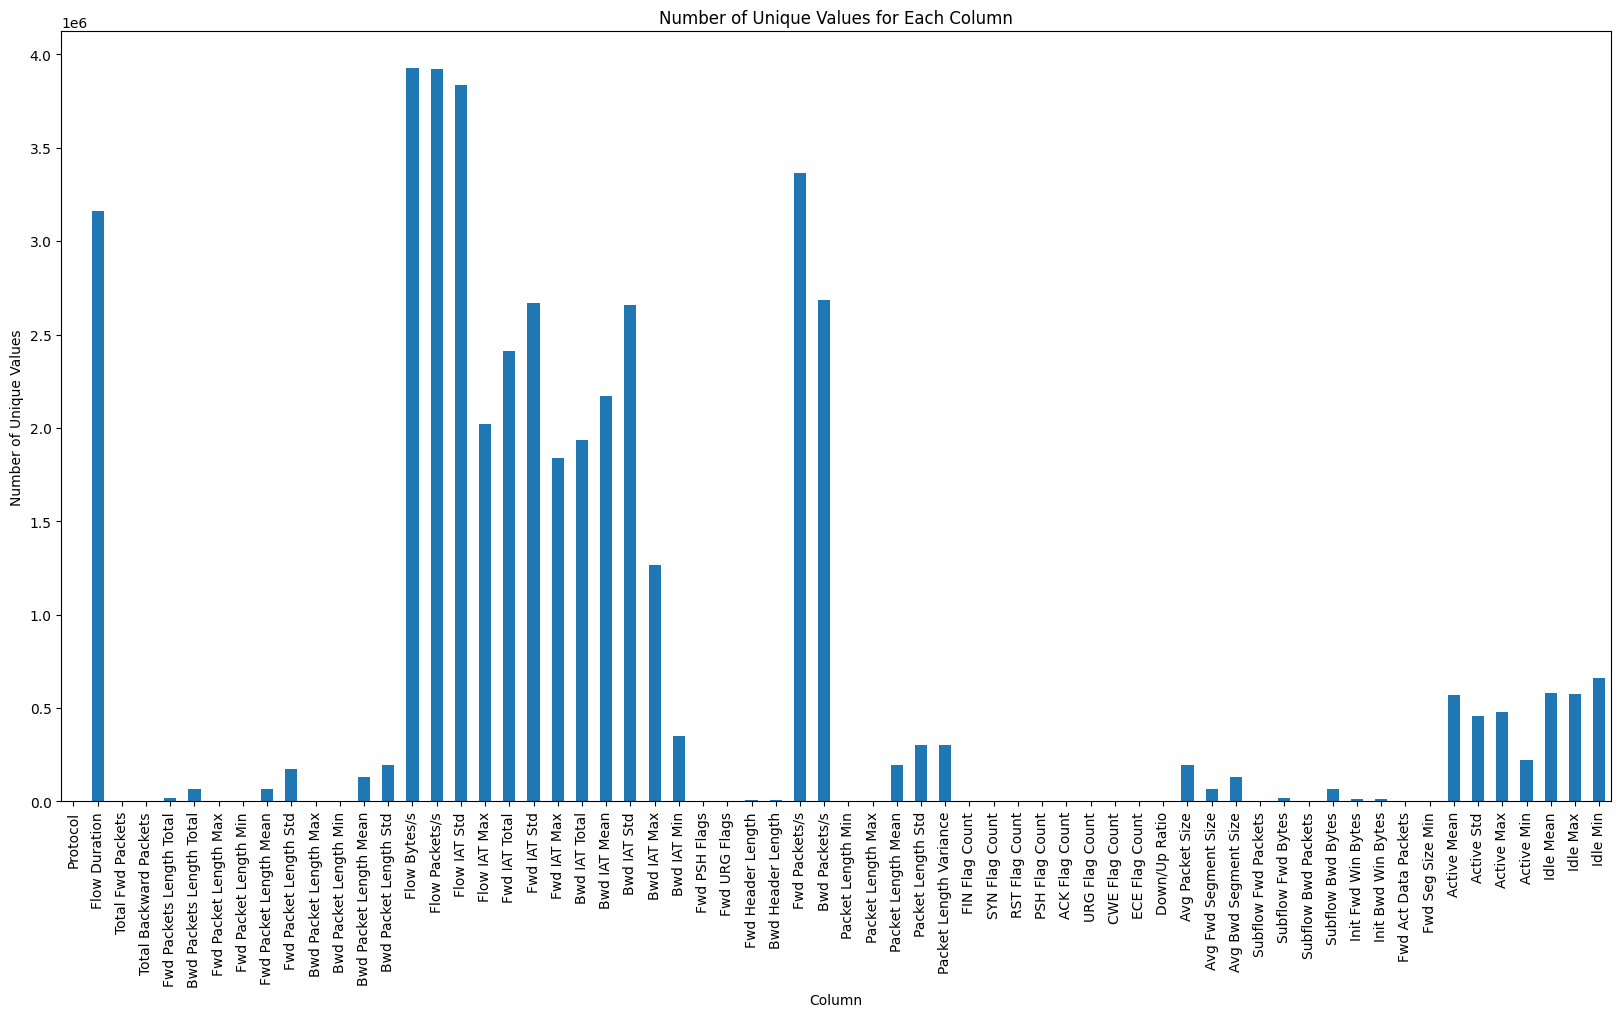

In [24]:
# plot a bar graph of the number of unique values for each column
plt.figure(figsize=(20, 10))
unique_values.plot(kind="bar")
plt.title("Number of Unique Values for Each Column")
plt.xlabel("Column")
plt.ylabel("Number of Unique Values")
plt.show()

In [25]:
# plot multiple graphs using dtypes
# get the number of columns for each dtype
dtype_counts = X_selected_features.dtypes.value_counts()

dtype_counts

float32    19
int32      15
float64    13
int8       12
int16       4
int64       1
Name: count, dtype: int64

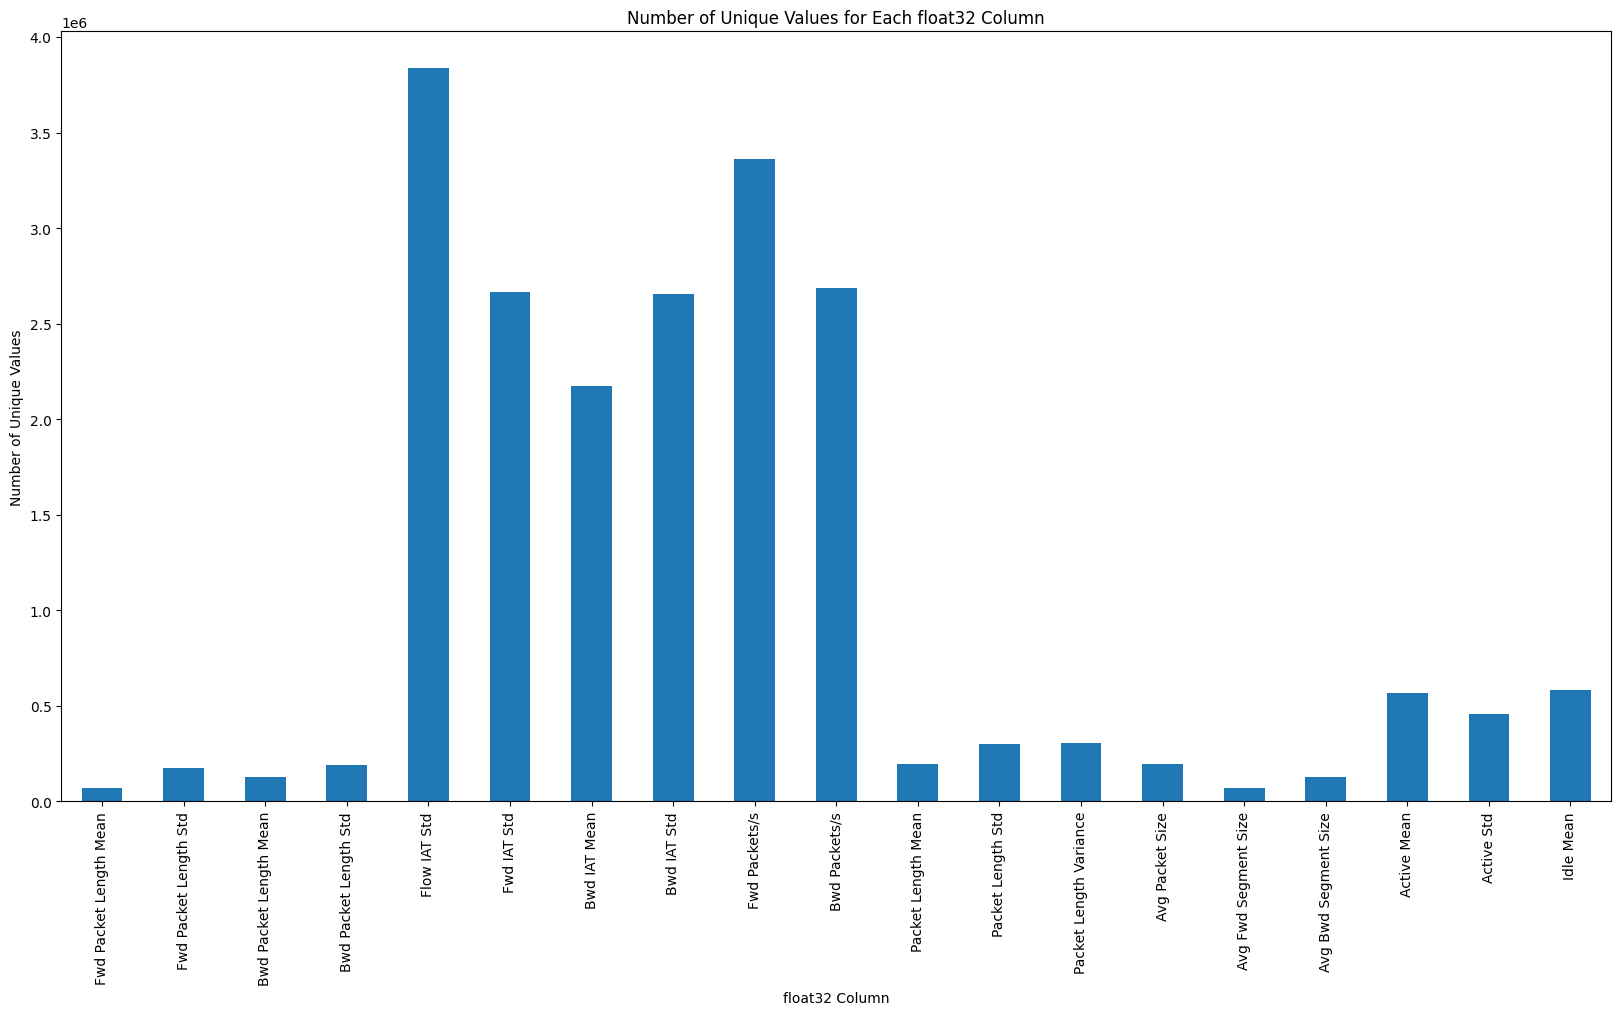

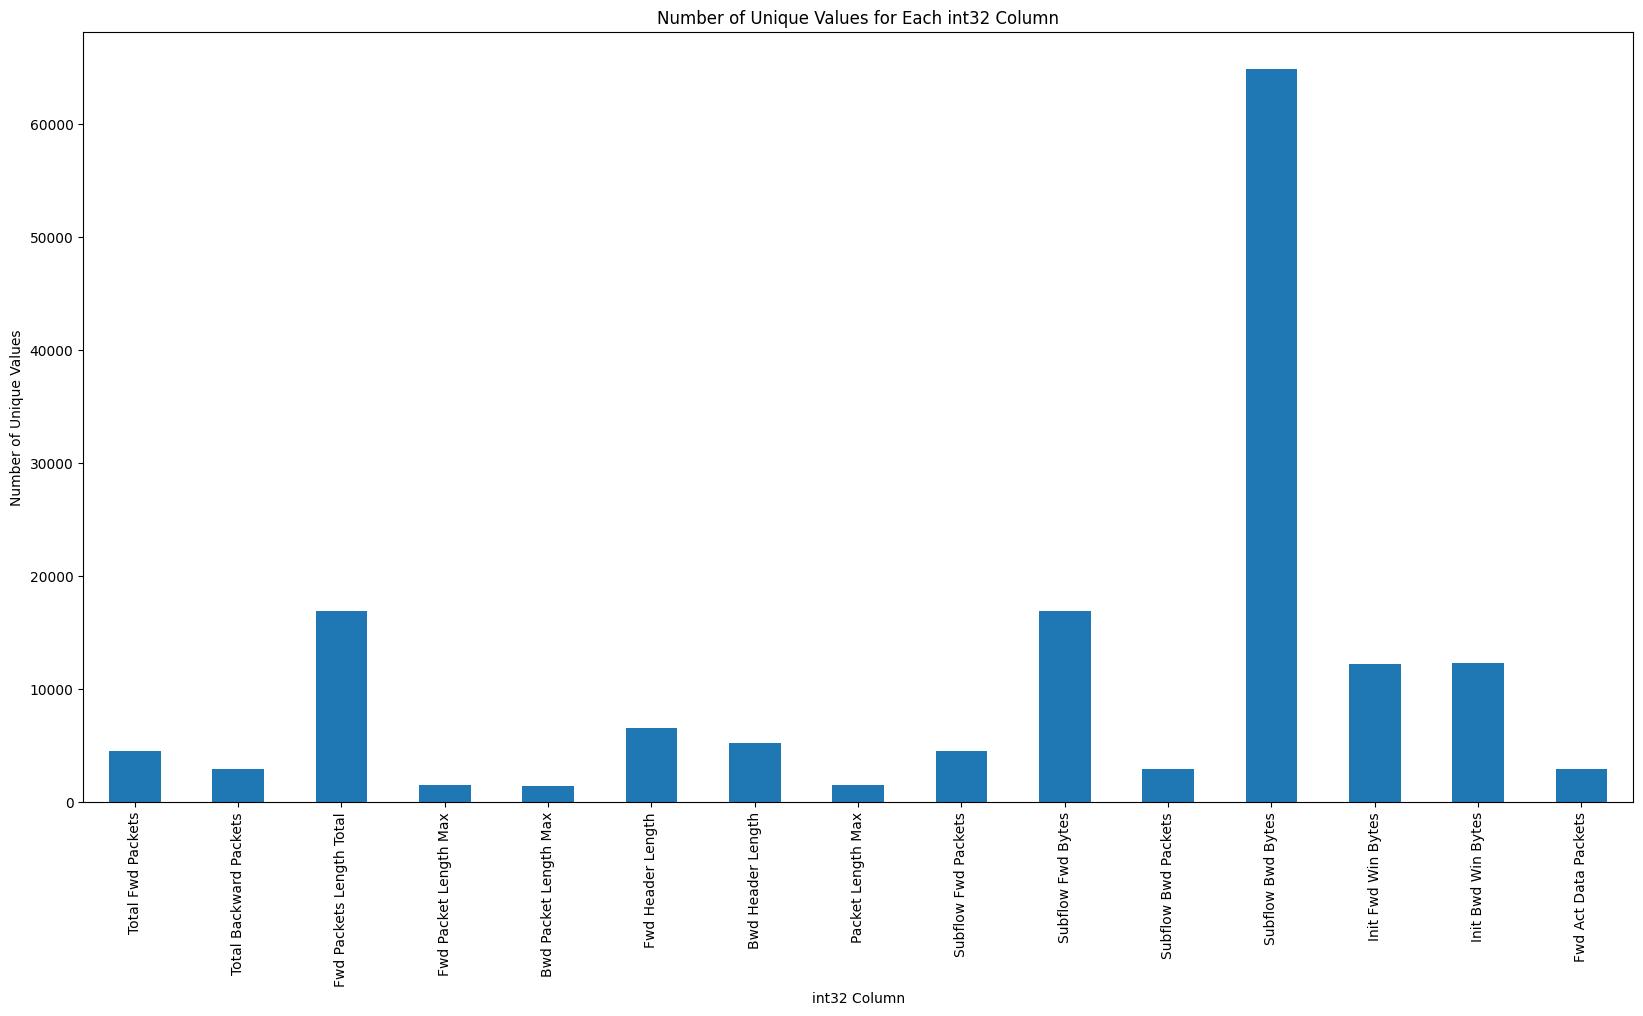

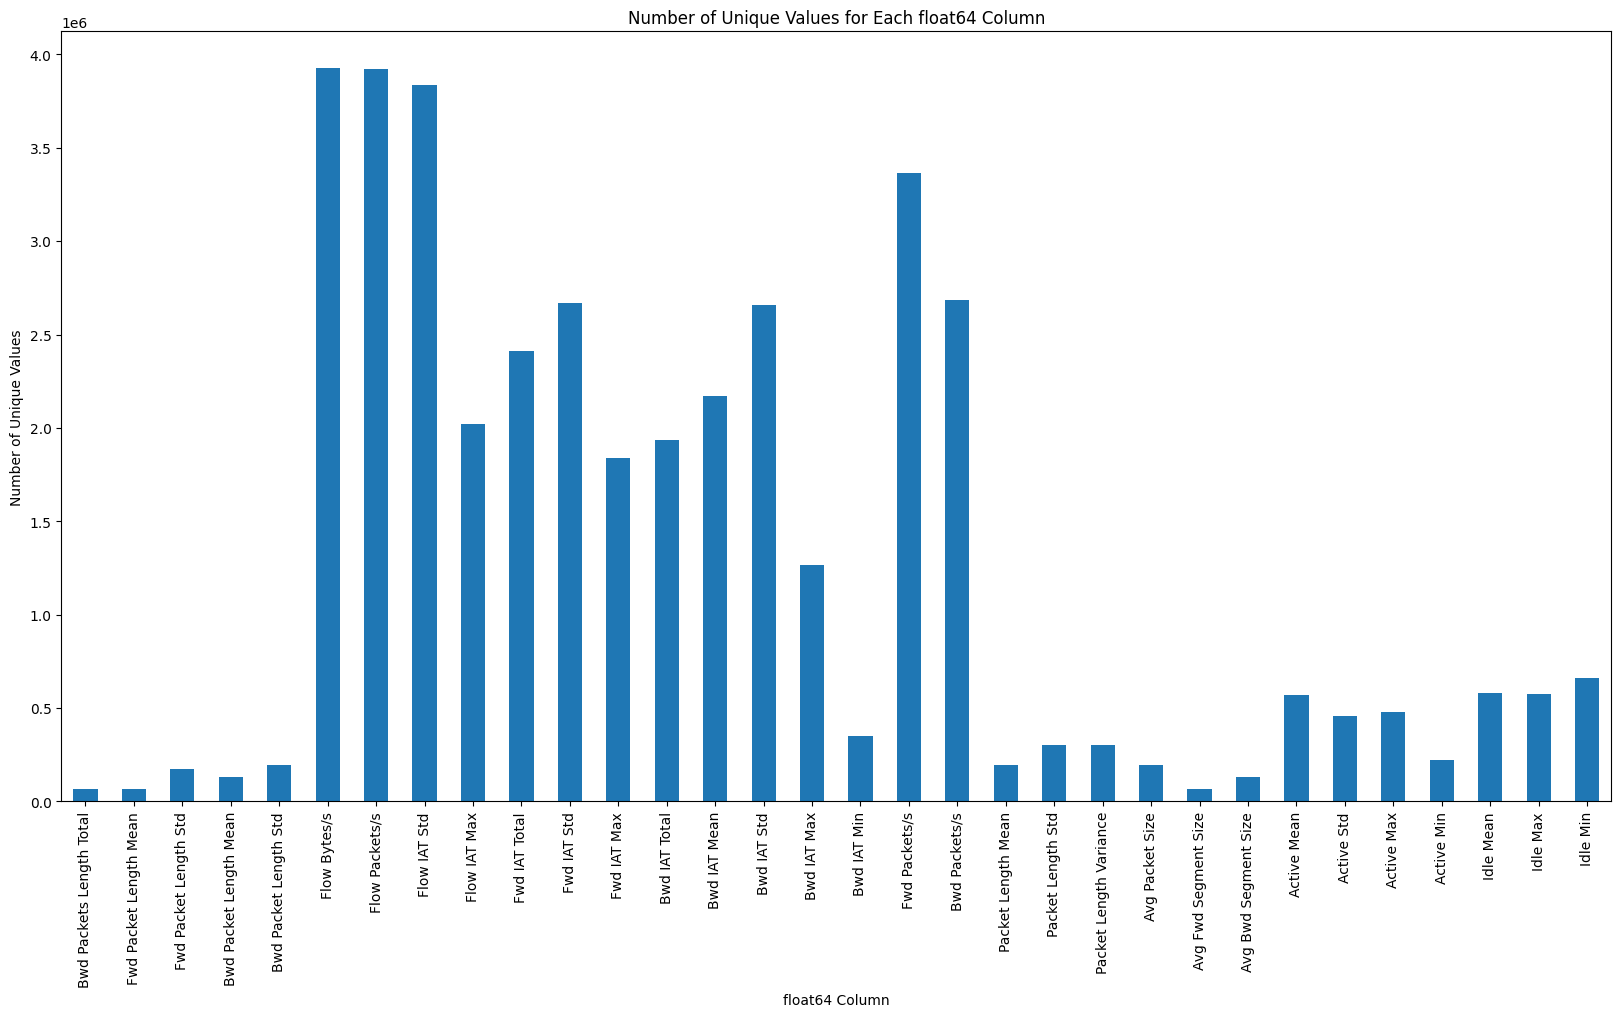

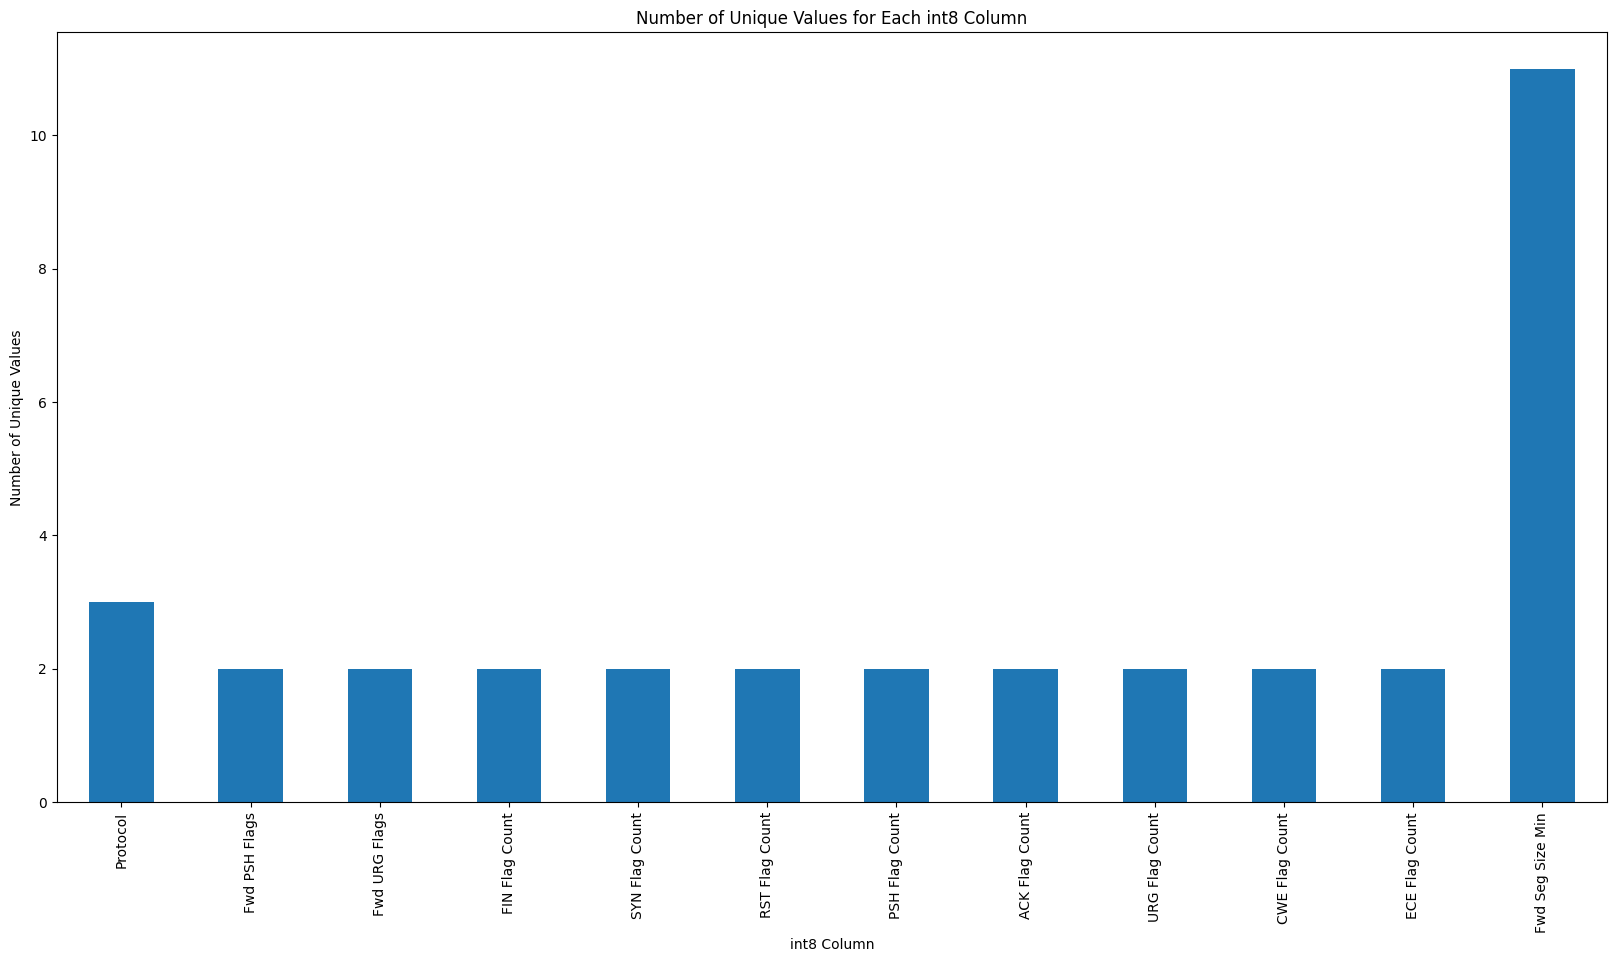

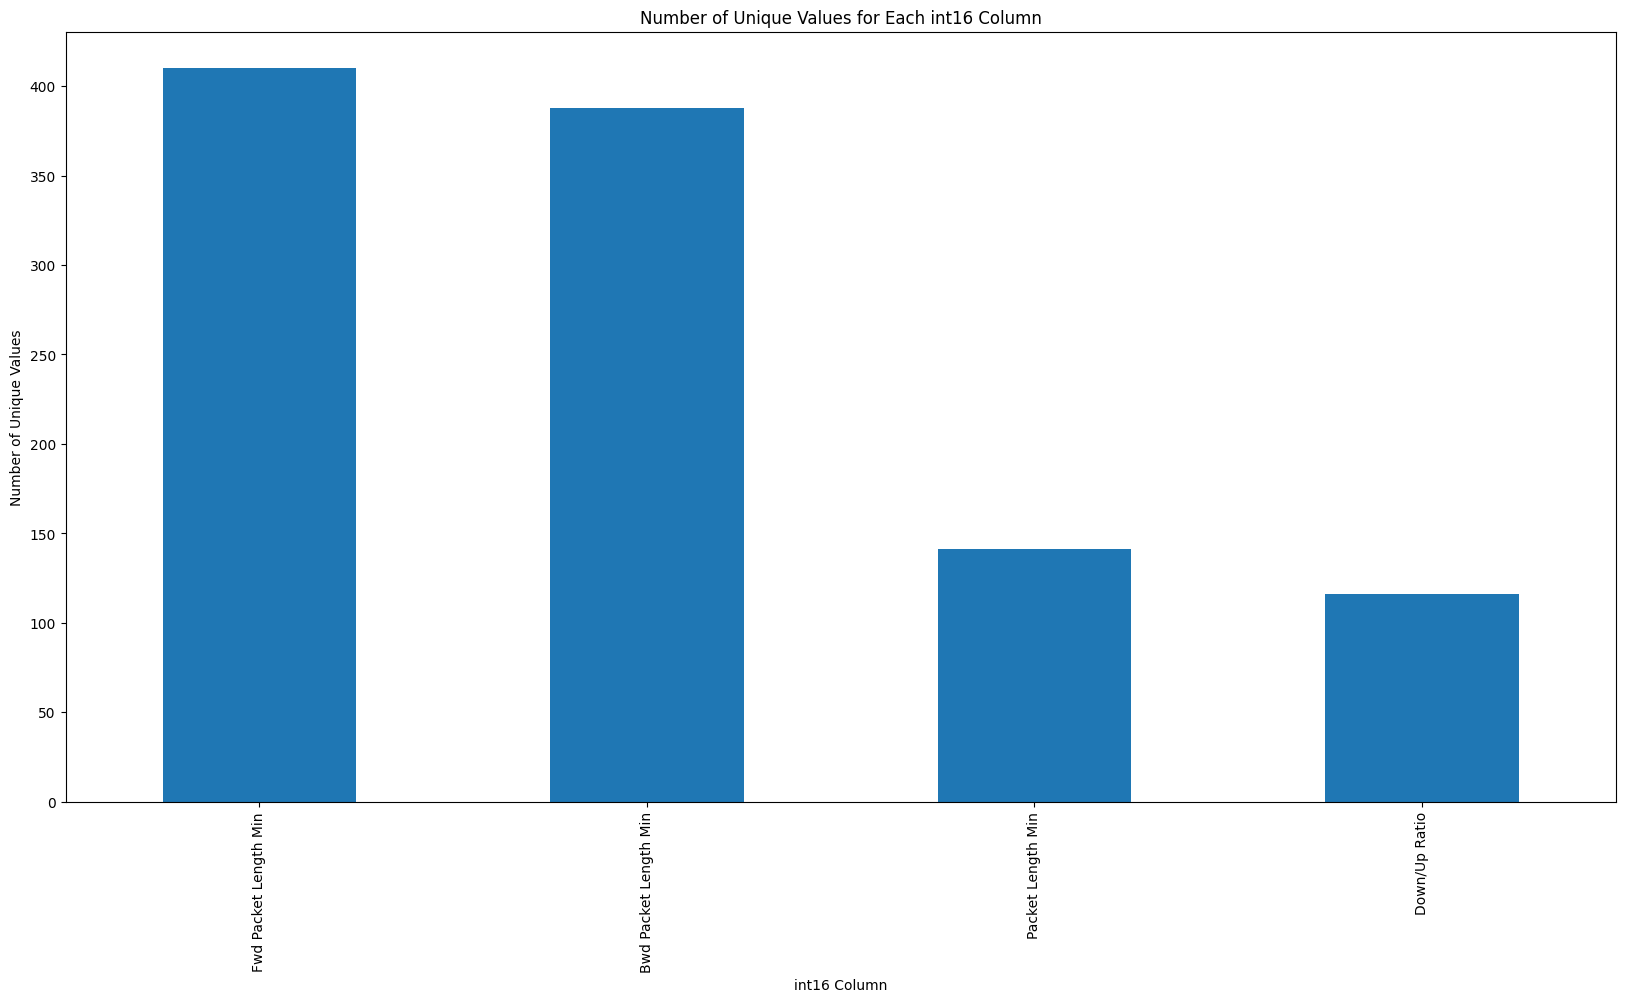

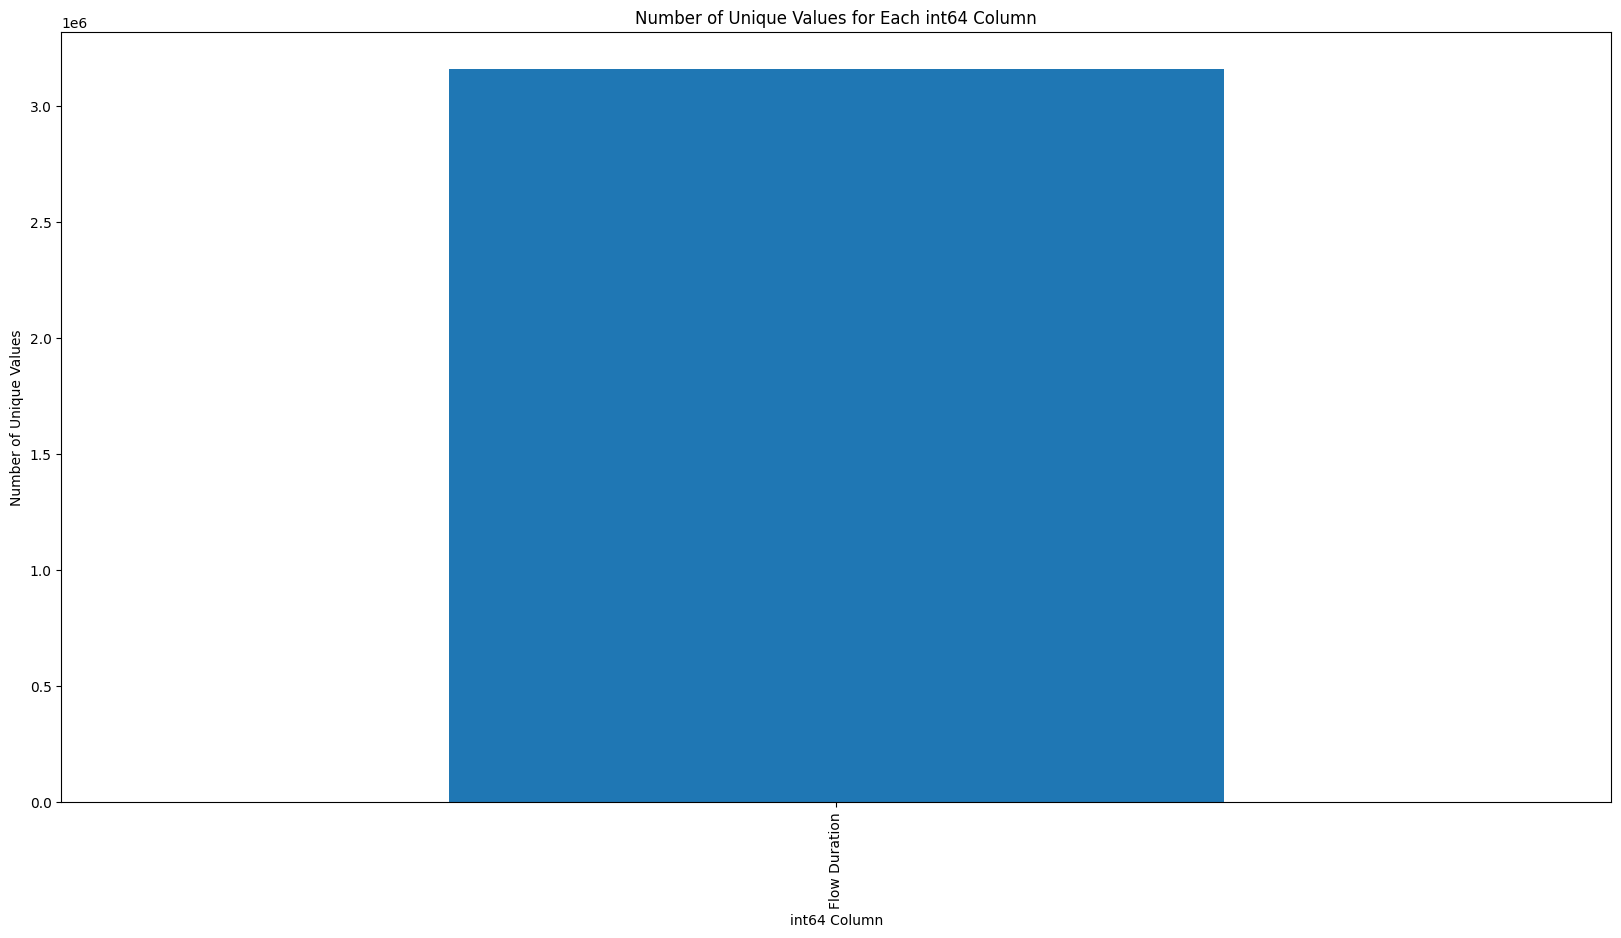

In [26]:
# plot graphs for each dtype
for dtype in dtype_counts.index:
    plt.figure(figsize=(20, 10))
    X_selected_features.select_dtypes(include=dtype).nunique().plot(kind="bar")
    plt.title(f"Number of Unique Values for Each {dtype} Column")
    plt.xlabel(f"{dtype} Column")
    plt.ylabel("Number of Unique Values")
    plt.show()

    

In [27]:
def analyze_ranges(df):
    range_analysis = {}
    for col in df.columns:
        unique_values = df[col].nunique()
        total_values = len(df[col])
        std_dev = df[col].std()
        iqr = df[col].quantile(0.75) - df[col].quantile(0.25)

        range_analysis[col] = {
            "dtype": str(df[col].dtype),
            "unique_values": unique_values,
            "unique_ratio": unique_values / total_values,
            "std_dev": std_dev,
            "iqr": iqr,
        }
    return pd.DataFrame(range_analysis).T

analyze_ranges(X_selected_features)

,dtype,unique_values,unique_ratio,std_dev,iqr
Protocol,int8,3,0.0,4.544056,0.0
Flow Duration,int64,3161639,0.474754,770488304.263213,5142468.5
Total Fwd Packets,int32,4565,0.000685,2373.86288,5.0
Total Backward Packets,int32,2968,0.000446,197.521585,4.0
Fwd Packets Length Total,int32,16899,0.002538,97025.74324,915.0
...,...,...,...,...,...
Active Max,float64,480931,0.072217,2196363.395124,0.0
Active Min,float64,223075,0.033497,1422507.790082,0.0
Idle Mean,float32,581252,0.087281,410413152.0,0.0
Idle Max,float64,577337,0.086693,976227880.670631,0.0


In [28]:
def bucket_cardinality(df):
    unique_counts = df.nunique()
    percentiles = unique_counts.describe(percentiles=[0.25, 0.5, 0.75])

    buckets = {
        "Low Cardinality (<= 25th %)": percentiles["25%"],
        "Moderate Cardinality (25th-75th %)": percentiles["75%"],
        "High Cardinality (> 75th %)": percentiles["max"]
    }
    return buckets

bucket_cardinality(X_selected_features)


{'Low Cardinality (<= 25th %)': 1199.0,
 'Moderate Cardinality (25th-75th %)': 578315.75,
 'High Cardinality (> 75th %)': 3926087.0}

In [29]:
import numpy as np

In [30]:
def detect_gaps(df):
    gap_analysis = {}
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            sorted_vals = sorted(df[col].dropna().unique())
            gaps = [sorted_vals[i + 1] - sorted_vals[i] for i in range(len(sorted_vals) - 1)]
            gap_analysis[col] = {
                "max_gap": max(gaps) if gaps else None,
                "mean_gap": sum(gaps) / len(gaps) if gaps else None,
                "std_gap": pd.Series(gaps).std() if gaps else None,
            }
    return pd.DataFrame(gap_analysis).T

gap = detect_gaps(X_selected_features)

In [31]:
from IPython.display import display, HTML

display(HTML(gap.to_html()))

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,max_gap,mean_gap,std_gap
Protocol,1.100000e+01,8.500000e+00,3.535534e+00
Flow Duration,2.559510e+11,2.907135e+05,1.917238e+08
Total Fwd Packets,2.958600e+04,6.784137e+01,5.948882e+02
Total Backward Packets,5.185000e+04,4.149579e+01,1.012827e+03
Fwd Packets Length Total,1.026262e+08,8.544907e+03,8.193914e+05
Bwd Packets Length Total,5.519921e+07,2.409177e+03,2.592425e+05
Fwd Packet Length Max,1.288800e+04,4.304609e+01,5.246557e+02
Fwd Packet Length Min,3.700000e+01,3.569682e+00,4.425933e+00
Fwd Packet Length Mean,2.935571e+03,2.406925e-01,2.006908e+01
Fwd Packet Length Std,4.151612e+03,1.066208e-01,1.447260e+01


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


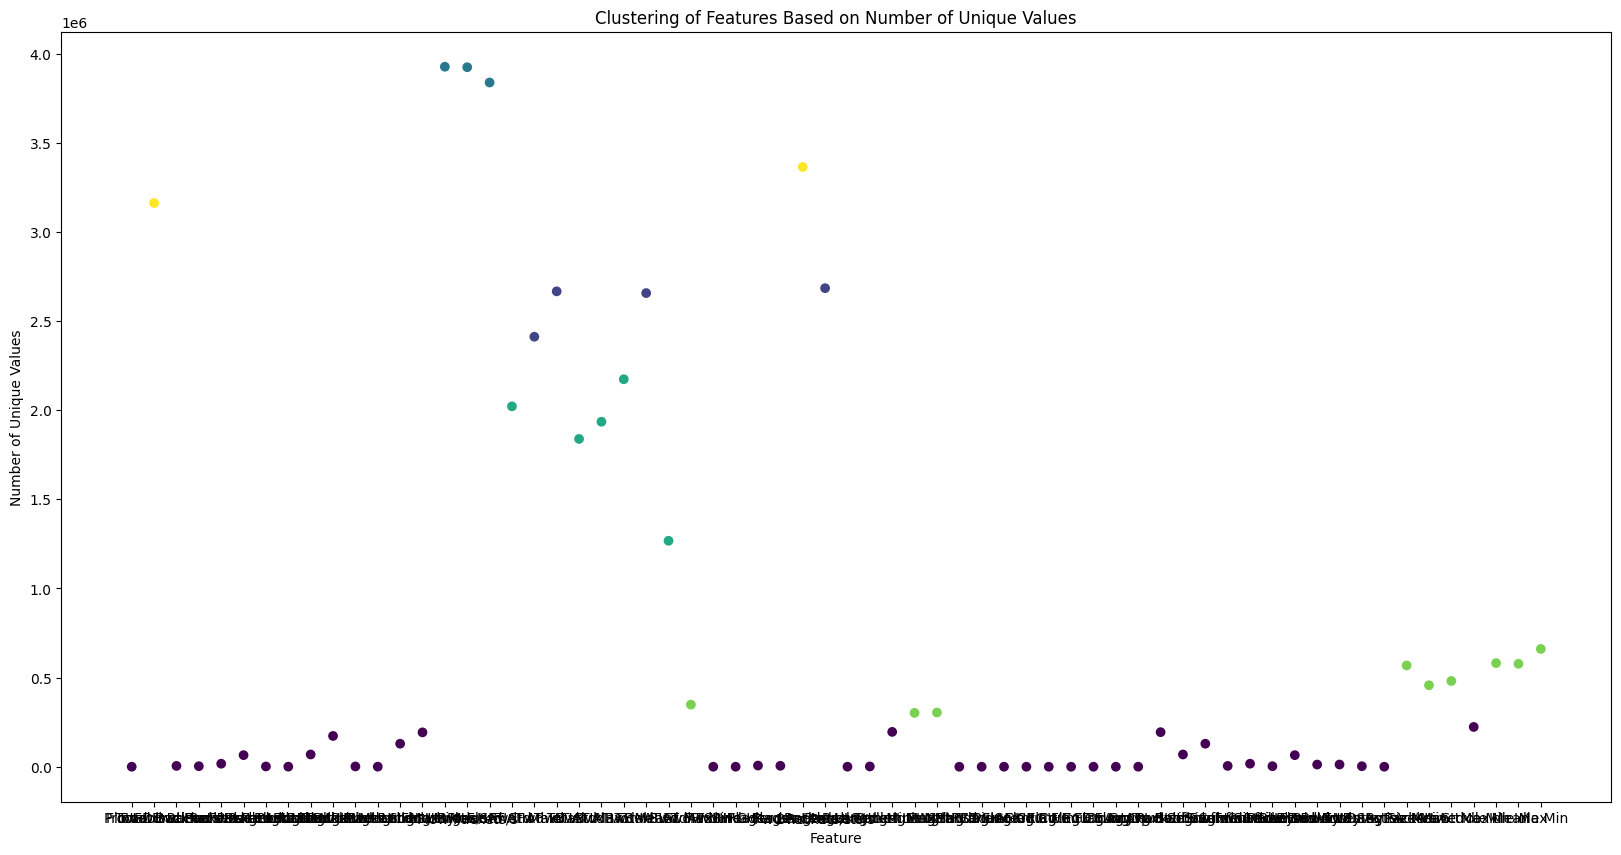

In [32]:
# cluster features based on the number of unique values and plot a graph
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
X_cluster = kmeans.fit_predict(unique_values.values.reshape(-1, 1))

plt.figure(figsize=(20, 10))

plt.scatter(unique_values.index, unique_values, c=X_cluster, cmap="viridis")

plt.title("Clustering of Features Based on Number of Unique Values")
plt.xlabel("Feature")
plt.ylabel("Number of Unique Values")
plt.show()

In [33]:
# sorted list of unique values
sorted_unique_values = unique_values.sort_values()



sorted_unique_values.tail(20)

Active Std         456785
Active Max         480931
Active Mean        567922
Idle Max           577337
Idle Mean          581252
Idle Min           660655
Bwd IAT Max       1267245
Fwd IAT Max       1838515
Bwd IAT Total     1934810
Flow IAT Max      2021257
Bwd IAT Mean      2173255
Fwd IAT Total     2411698
Bwd IAT Std       2656507
Fwd IAT Std       2666295
Bwd Packets/s     2684123
Flow Duration     3161639
Fwd Packets/s     3363657
Flow IAT Std      3837516
Flow Packets/s    3923285
Flow Bytes/s      3926087
dtype: int64

In [34]:
sorted_unique_values.head(20)

Fwd URG Flags               2
Fwd PSH Flags               2
URG Flag Count              2
CWE Flag Count              2
ECE Flag Count              2
FIN Flag Count              2
RST Flag Count              2
SYN Flag Count              2
PSH Flag Count              2
ACK Flag Count              2
Protocol                    3
Fwd Seg Size Min           11
Down/Up Ratio             116
Packet Length Min         141
Bwd Packet Length Min     388
Fwd Packet Length Min     410
Bwd Packet Length Max    1462
Fwd Packet Length Max    1498
Packet Length Max        1522
Fwd Act Data Packets     2896
dtype: int64

In [35]:
import cudf

In [36]:
type(unique_values)

pandas.core.series.Series

In [37]:
unique_values

Protocol                          3
Flow Duration               3161639
Total Fwd Packets              4565
Total Backward Packets         2968
Fwd Packets Length Total      16899
                             ...   
Active Max                   480931
Active Min                   223075
Idle Mean                    581252
Idle Max                     577337
Idle Min                     660655
Length: 64, dtype: int64

In [38]:
pd

<module 'pandas' from '/usr/local/lib/python3.10/dist-packages/pandas/__init__.py'>

In [39]:
# group features based on the range of unique values, with bins being lower limits
unique_values_range = pd.cut(unique_values, bins=[0, 100, 1000, 10000, 100000, 1000000, 10000000], right=False)

unique_values_range

Protocol                               [0, 100)
Flow Duration               [1000000, 10000000)
Total Fwd Packets                 [1000, 10000)
Total Backward Packets            [1000, 10000)
Fwd Packets Length Total        [10000, 100000)
                                   ...         
Active Max                    [100000, 1000000)
Active Min                    [100000, 1000000)
Idle Mean                     [100000, 1000000)
Idle Max                      [100000, 1000000)
Idle Min                      [100000, 1000000)
Length: 64, dtype: category
Categories (6, interval[int64, left]): [[0, 100) < [100, 1000) < [1000, 10000) < [10000, 100000) < [100000, 1000000) < [1000000, 10000000)]

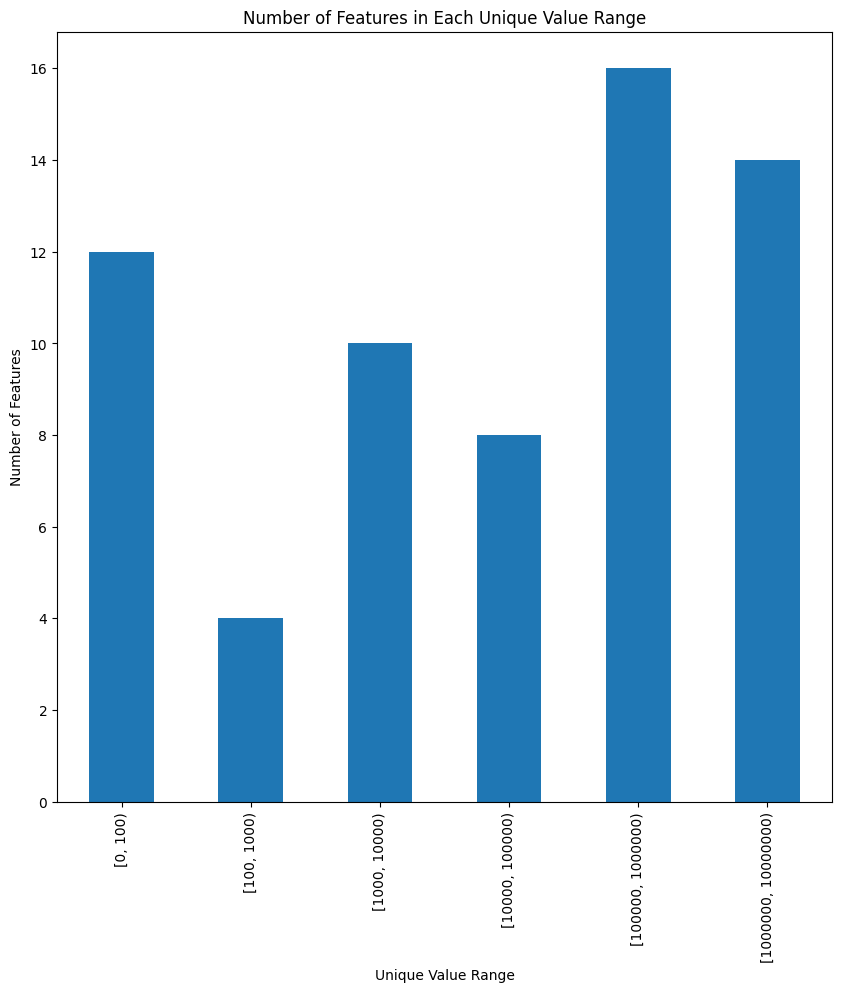

In [40]:
# plot a bar graph of the number of unique values for each range
plt.figure(figsize=(10, 10))
unique_values_range.value_counts().sort_index().plot(kind="bar")
plt.title("Number of Features in Each Unique Value Range")
plt.xlabel("Unique Value Range")
plt.ylabel("Number of Features")
plt.show()

## Column by Column Analysis
Need to determine for each column the best encoding method to use.

In [41]:
# get all columns with int16 and int8 dtypes
int16_columns = X_selected_features.select_dtypes(include="int16").columns
int8_columns = X_selected_features.select_dtypes(include="int8").columns
int32_columns = X_selected_features.select_dtypes(include="int32").columns
int64_columns = X_selected_features.select_dtypes(include="int64").columns

int16_columns, int8_columns, int32_columns, int64_columns

(Index(['Fwd Packet Length Min', 'Bwd Packet Length Min', 'Packet Length Min',
        'Down/Up Ratio'],
       dtype='object'),
 Index(['Protocol', 'Fwd PSH Flags', 'Fwd URG Flags', 'FIN Flag Count',
        'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count',
        'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count',
        'Fwd Seg Size Min'],
       dtype='object'),
 Index(['Total Fwd Packets', 'Total Backward Packets',
        'Fwd Packets Length Total', 'Fwd Packet Length Max',
        'Bwd Packet Length Max', 'Fwd Header Length', 'Bwd Header Length',
        'Packet Length Max', 'Subflow Fwd Packets', 'Subflow Fwd Bytes',
        'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Init Fwd Win Bytes',
        'Init Bwd Win Bytes', 'Fwd Act Data Packets'],
       dtype='object'),
 Index(['Flow Duration'], dtype='object'))

In [42]:
int8_ranges = {}
for col in int8_columns:
    int8_ranges[col] = {
        "min": X_selected_features[col].min(),
        "max": X_selected_features[col].max(),
        "unique_values": X_selected_features[col].nunique(),
    }

int8_ranges_df = pd.DataFrame(int8_ranges).T

int8_ranges_df

,min,max,unique_values
Protocol,0,17,3
Fwd PSH Flags,0,1,2
Fwd URG Flags,0,1,2
FIN Flag Count,0,1,2
SYN Flag Count,0,1,2
RST Flag Count,0,1,2
PSH Flag Count,0,1,2
ACK Flag Count,0,1,2
URG Flag Count,0,1,2
CWE Flag Count,0,1,2


In [43]:
# for each int16 column, get the range of values of the column and the number of unique values
int16_ranges = {}
for col in int16_columns:
    int16_ranges[col] = {
        "min": X_selected_features[col].min(),
        "max": X_selected_features[col].max(),
        "unique_values": X_selected_features[col].nunique(),
    }

int16_ranges_df = pd.DataFrame(int16_ranges).T

int16_ranges_df

,min,max,unique_values
Fwd Packet Length Min,0,1460,410
Bwd Packet Length Min,0,1460,388
Packet Length Min,0,1460,141
Down/Up Ratio,0,237,116


In [44]:
int32_ranges = {}
for col in int32_columns:
    int32_ranges[col] = {
        "min": X_selected_features[col].min(),
        "max": X_selected_features[col].max(),
        "unique_values": X_selected_features[col].nunique(),
    }

int32_ranges_df = pd.DataFrame(int32_ranges).T

int32_ranges_df

,min,max,unique_values
Total Fwd Packets,1,309629,4565
Total Backward Packets,0,123118,2968
Fwd Packets Length Total,0,144391846,16899
Fwd Packet Length Max,0,64440,1498
Bwd Packet Length Max,0,65160,1462
Fwd Header Length,0,2477032,6568
Bwd Header Length,0,2462372,5263
Packet Length Max,0,65160,1522
Subflow Fwd Packets,1,309629,4565
Subflow Fwd Bytes,0,144391846,16899


In [45]:
int64_ranges = {}
for col in int64_columns:
    int64_ranges[col] = {
        "min": X_selected_features[col].min(),
        "max": X_selected_features[col].max(),
        "unique_values": X_selected_features[col].nunique(),
    }

int64_ranges_df = pd.DataFrame(int64_ranges).T

int64_ranges_df

,min,max,unique_values
Flow Duration,-919011000000,120000000,3161639


In [46]:
float32_columns = X_selected_features.select_dtypes(include="float32").columns
float64_columns = X_selected_features.select_dtypes(include="float64").columns

float32_columns, float64_columns

(Index(['Fwd Packet Length Mean', 'Fwd Packet Length Std',
        'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Std',
        'Fwd IAT Std', 'Bwd IAT Mean', 'Bwd IAT Std', 'Fwd Packets/s',
        'Bwd Packets/s', 'Packet Length Mean', 'Packet Length Std',
        'Packet Length Variance', 'Avg Packet Size', 'Avg Fwd Segment Size',
        'Avg Bwd Segment Size', 'Active Mean', 'Active Std', 'Idle Mean'],
       dtype='object'),
 Index(['Bwd Packets Length Total', 'Flow Bytes/s', 'Flow Packets/s',
        'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Max', 'Bwd IAT Total',
        'Bwd IAT Max', 'Bwd IAT Min', 'Active Max', 'Active Min', 'Idle Max',
        'Idle Min'],
       dtype='object'))

In [47]:
float32_ranges = {}
for col in float32_columns:
    float32_ranges[col] = {
        "min": X_selected_features[col].min(),
        "max": X_selected_features[col].max(),
        "unique_values": X_selected_features[col].nunique(),
    }

float32_ranges_df = pd.DataFrame(float32_ranges).T

float32_ranges_df

,min,max,unique_values
Fwd Packet Length Mean,0.0,1.652931e+04,68675.0
Fwd Packet Length Std,0.0,1.840158e+04,172590.0
Bwd Packet Length Mean,0.0,3.387929e+04,129001.0
Bwd Packet Length Std,0.0,2.132624e+04,192728.0
Flow IAT Std,0.0,4.743545e+11,3837516.0
Fwd IAT Std,0.0,4.743545e+11,2666295.0
Bwd IAT Mean,0.0,1.200000e+08,2173255.0
Bwd IAT Std,0.0,8.480000e+07,2656507.0
Fwd Packets/s,0.0,4.000000e+06,3363657.0
Bwd Packets/s,0.0,2.000000e+06,2684123.0


In [48]:
float64_ranges = {}
for col in float64_columns:
    float64_ranges[col] = {
        "min": X_selected_features[col].min(),
        "max": X_selected_features[col].max(),
        "unique_values": X_selected_features[col].nunique(),
    }

float64_ranges_df = pd.DataFrame(float64_ranges).T

float64_ranges_df

,min,max,unique_values
Bwd Packets Length Total,0.000000e+00,1.563604e+08,64903.0
Flow Bytes/s,0.000000e+00,1.806643e+09,3926087.0
Flow Packets/s,-8.895325e-03,4.000000e+06,3923285.0
Flow IAT Max,-8.282200e+11,9.797810e+11,2021257.0
Fwd IAT Total,-9.190110e+11,1.200000e+08,2411698.0
Fwd IAT Max,-8.282200e+11,9.797810e+11,1838515.0
Bwd IAT Total,0.000000e+00,1.200000e+08,1934810.0
Bwd IAT Max,0.000000e+00,1.200000e+08,1267245.0
Bwd IAT Min,0.000000e+00,1.200000e+08,348262.0
Active Max,0.000000e+00,1.140000e+08,480931.0


In [49]:
# binary encode all values from int16 columns to 16 bits
int16_binary_df = X_selected_features[int16_columns].map(lambda x: format(x, "016b"))

int16_binary_df.head()

,Fwd Packet Length Min,Bwd Packet Length Min,Packet Length Min,Down/Up Ratio
0,0000000000000000,0000000000000000,0000000000000000,0000000000000000
1,0000000000000000,0000000000000000,0000000000000000,0000000000000000
2,0000000000000000,0000000000000000,0000000000000000,0000000000000001
3,0000000000000000,0000000000000000,0000000000000000,0000000000000000
4,0000000000000000,0000000000000000,0000000000000000,0000000000000001


In [50]:
# get all columns from int32_columns where the max and min values are within the range of 16 bits, i.e. 0 to 65535
int32_int16_range = int32_ranges_df[
    (int32_ranges_df["min"] >= 0) & (int32_ranges_df["max"] <= (2**16) - 1)
]

int32_int16_range

,min,max,unique_values
Fwd Packet Length Max,0,64440,1498
Bwd Packet Length Max,0,65160,1462
Packet Length Max,0,65160,1522


In [51]:
int16_int32_binary_df = X_selected_features[int32_int16_range.index].map(lambda x: format(x, "016b"))

int16_int32_binary_df.head()

,Fwd Packet Length Max,Bwd Packet Length Max,Packet Length Max
0,0000000011001010,0000010110110100,0000010110110100
1,0000000000100110,0000000000000000,0000000000100110
2,0000000110000001,0000010110110100,0000010110110100
3,0000000000000000,0000000000000000,0000000000000000
4,0000001000000101,0000010110110100,0000010110110100


In [52]:
# get difference of columns in int32_columns and int32_int16_range
int32_remaining = int32_ranges_df.index.difference(int32_int16_range.index)

int32_remaining

Index(['Bwd Header Length', 'Fwd Act Data Packets', 'Fwd Header Length',
       'Fwd Packets Length Total', 'Init Bwd Win Bytes', 'Init Fwd Win Bytes',
       'Subflow Bwd Bytes', 'Subflow Bwd Packets', 'Subflow Fwd Bytes',
       'Subflow Fwd Packets', 'Total Backward Packets', 'Total Fwd Packets'],
      dtype='object')

# Come back to this later!! Handling negative values

In [53]:
# get analysis of the remaining int32 columns
int32_remaining_ranges = int32_ranges_df.loc[int32_remaining]

int32_remaining_ranges

,min,max,unique_values
Bwd Header Length,0,2462372,5263
Fwd Act Data Packets,0,309628,2896
Fwd Header Length,0,2477032,6568
Fwd Packets Length Total,0,144391846,16899
Init Bwd Win Bytes,-1,65535,12326
Init Fwd Win Bytes,-1,65535,12258
Subflow Bwd Bytes,0,156360426,64901
Subflow Bwd Packets,0,123118,2968
Subflow Fwd Bytes,0,144391846,16899
Subflow Fwd Packets,1,309629,4565


## Wide-range Values

In [54]:
import tqdm
import threading
import functools

Wrapper function to show progress of long running functions especially when plotting data with a large number of features.

In [55]:
def provide_progress_bar(function, estimated_time=None, tstep=0.2, tqdm_kwargs={}, args=[], kwargs={}):
    """Tqdm wrapper for a long-running function

    source: https://gist.github.com/duckythescientist/c06d87617b5d6ac1e00a622df760709d

    args:
        function - function to run
        estimated_time - how long you expect the function to take
        tstep - time delta (seconds) for progress bar updates
        tqdm_kwargs - kwargs to construct the progress bar
        args - args to pass to the function
        kwargs - keyword args to pass to the function
    ret:
        function(*args, **kwargs)
    """
    ret = [None]  # Mutable var so the function can store its return value
    def myrunner(function, ret, *args, **kwargs):
        ret[0] = function(*args, **kwargs)

    thread = threading.Thread(target=myrunner, args=(function, ret) + tuple(args), kwargs=kwargs)
    pbar = tqdm.tqdm(total=estimated_time if estimated_time else None,**tqdm_kwargs)

    thread.start()
    while thread.is_alive():
        thread.join(timeout=tstep)
        pbar.update(tstep)
    pbar.close()
    return ret[0]


def progress_wrapped(estimated_time, tstep=0.2, tqdm_kwargs={}):
    """Decorate a function to add a progress bar"""
    def real_decorator(function):
        @functools.wraps(function)
        def wrapper(*args, **kwargs):
            return provide_progress_bar(function, estimated_time=estimated_time, tstep=tstep, tqdm_kwargs=tqdm_kwargs, args=args, kwargs=kwargs)
        return wrapper
    return real_decorator

In [56]:
import seaborn as sns
from scipy import stats
import numpy as np

def analyze_distribution(column_name: pd.Series, figsize=(15,10)):

    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=figsize)

    # pp.pprint(f"Analysis of {column_name.name}")
    # pp.pprint("-" * 50)

    # pp.pprint("plotting histogram with density plot")

    sns.histplot(column_name, kde=True, ax=ax1)
    ax1.set_title("Histogram with Density Plot")
    ax1.set_xlabel("Value")
    ax1.set_ylabel("Count")


    # pp.pprint("plotting boxplot")


    sns.boxplot(x=column_name, ax=ax2)
    ax2.set_title("Boxplot")


    # pp.pprint("plotting Q-Q plot")


    stats.probplot(column_name, plot=ax3)
    ax3.set_title("Q-Q Plot")

    # pp.pprint("plotting ECDF plot")

    sns.ecdfplot(column_name, ax=ax4)
    ax4.set_title("ECDF Plot")
    ax4.set_xlabel("Value")
    ax4.set_ylabel("ECDF")

    plt.tight_layout()
    plt.show()

    # print statistical measures
    pp.pprint(f"Distribution Analysis for {column_name.name}")
    pp.pprint("-" * 50)
    pp.pprint(f"Unique values: {column_name.nunique()}")
    pp.pprint("Basic Statistics:")
    pp.pprint(column_name.describe())

    print()

    # print skewness and kurtosis
    skewness = column_name.skew()
    kurtosis = column_name.kurtosis()

    pp.pprint(f"Skewness: {skewness:.2f}")
    pp.pprint(f"Kurtosis: {kurtosis:.2f}")

    print()

    # shapiro-wilk test
    statistic, p_value = stats.shapiro(column_name.sample(min(5000, len(column_name))))
    pp.pprint(f"Shapiro-Wilk Test: Statistic={statistic:.2f}, p-value={p_value:.2f}")

    print()

    # gaps in the distribution
    sorted_vals = sorted(column_name.unique())
    
    if len(sorted_vals) > 1:
        gaps = np.diff(sorted_vals)
        max_gap = gaps.max()
        mean_gap = gaps.mean()

        pp.pprint("Distribution Gaps:")
        pp.pprint("-" * 50)
        pp.pprint(f"Max Gap: {max_gap}")
        pp.pprint(f"Mean Gap: {mean_gap}")
        pp.pprint(f"Standard Deviation of Gaps: {gaps.std():.2f}")





  2%|▏         | 2.6/108 [00:03<04:06,  2.34s/it]/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
 29%|██▉       | 31.59999999999992/108 [00:34<02:34,  2.03s/it]/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
 33%|███▎      | 35.19999999999996/108 [00:52<10:33,  8.71s/it]

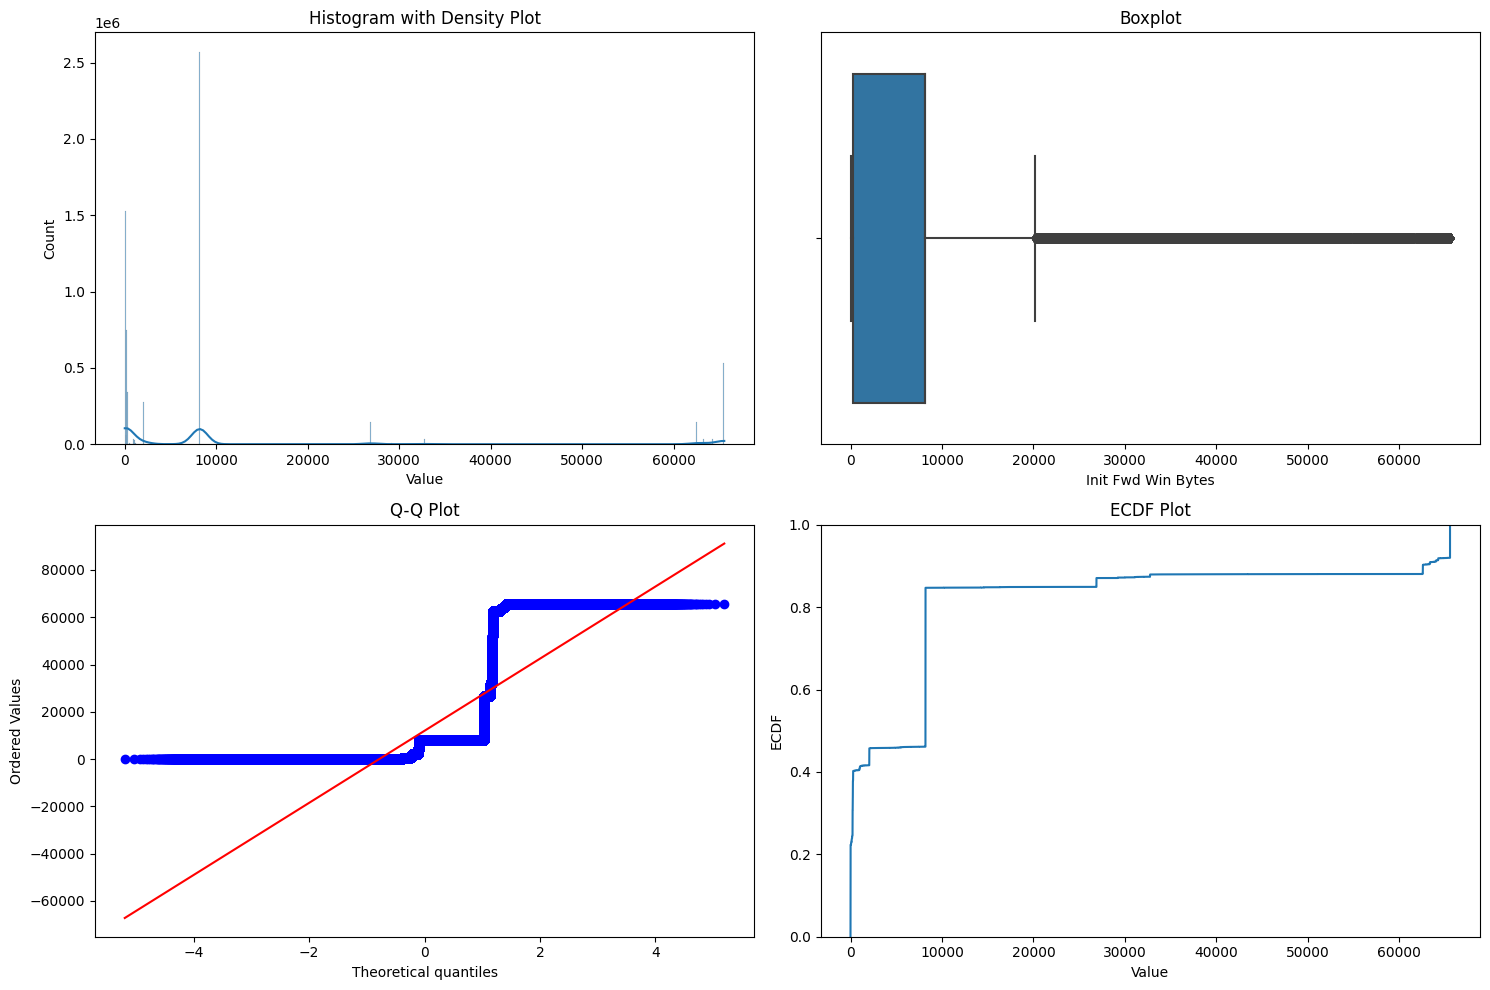

 33%|███▎      | 35.39999999999996/108 [00:52<07:44,  6.40s/it]

'Distribution Analysis for Init Fwd Win Bytes'
'--------------------------------------------------'
'Unique values: 12258'
'Basic Statistics:'
count    6.659532e+06
mean     1.198020e+04
std      2.024847e+04
min     -1.000000e+00
25%      2.190000e+02
50%      8.192000e+03
75%      8.192000e+03
max      6.553500e+04
Name: Init Fwd Win Bytes, dtype: float64

'Skewness: 2.04'
'Kurtosis: 2.59'



 33%|███▎      | 35.79999999999997/108 [00:53<01:47,  1.48s/it] 

'Shapiro-Wilk Test: Statistic=0.57, p-value=0.00'

'Distribution Gaps:'
'--------------------------------------------------'
'Max Gap: 177'
'Mean Gap: 5.346822224035245'
'Standard Deviation of Gaps: 9.60'


In [57]:
provide_progress_bar(analyze_distribution, estimated_time=108, args=(X_selected_features["Init Fwd Win Bytes"],))

In [58]:
def assess_distribution_type(column: pd.Series) -> str:
    unique_count = column.nunique()
    total_count = len(column)
    unique_ratio = unique_count / total_count

    values = column.dropna()
    range_size = values.max() - values.min()
    iqr = values.quantile(0.75) - values.quantile(0.25)

    sorted_vals = sorted(values.unique())
    gaps = np.diff(sorted_vals)
    max_gap = gaps.max() if len(gaps) > 0 else None
    mean_gap = gaps.mean() if len(gaps) > 0 else None
    gap_ratio = max_gap / mean_gap if max_gap is not None and mean_gap is not None else None

    reasons = []

    if unique_ratio > 0.1:
        reasons.append("High Cardinality")
    if iqr > 0 and iqr / range_size < 0.25:
        reasons.append("Narrow IQR")
    if gap_ratio is not None and gap_ratio > 10:
        reasons.append("Large Gaps")

    if len(reasons) >= 2:
        pp.pprint(f"WIDE RANGE: {reasons}")
    else:
        pp.pprint(f"MODERATE RANGE: {reasons}")
    
    print()

In [59]:
for column in float64_columns:
    print(column)
    assess_distribution_type(X_selected_features[column])

Bwd Packets Length Total
"WIDE RANGE: ['Narrow IQR', 'Large Gaps']"

Flow Bytes/s
"WIDE RANGE: ['High Cardinality', 'Narrow IQR', 'Large Gaps']"

Flow Packets/s
"WIDE RANGE: ['High Cardinality', 'Narrow IQR', 'Large Gaps']"

Flow IAT Max
"WIDE RANGE: ['High Cardinality', 'Narrow IQR', 'Large Gaps']"

Fwd IAT Total
"WIDE RANGE: ['High Cardinality', 'Narrow IQR', 'Large Gaps']"

Fwd IAT Max
"WIDE RANGE: ['High Cardinality', 'Narrow IQR', 'Large Gaps']"

Bwd IAT Total
"WIDE RANGE: ['High Cardinality', 'Narrow IQR', 'Large Gaps']"

Bwd IAT Max
"WIDE RANGE: ['High Cardinality', 'Narrow IQR', 'Large Gaps']"

Bwd IAT Min
"WIDE RANGE: ['Narrow IQR', 'Large Gaps']"

Active Max
"MODERATE RANGE: ['Large Gaps']"

Active Min
"MODERATE RANGE: ['Large Gaps']"

Idle Max
"MODERATE RANGE: ['Large Gaps']"

Idle Min
"MODERATE RANGE: ['Large Gaps']"



In [60]:
X_onehot_df.head()

,Protocol_0,Protocol_6,Protocol_17,Fwd Seg Size Min_0,Fwd Seg Size Min_8,Fwd Seg Size Min_20,Fwd Seg Size Min_24,Fwd Seg Size Min_28,Fwd Seg Size Min_32,Fwd Seg Size Min_36,Fwd Seg Size Min_40,Fwd Seg Size Min_44,Fwd Seg Size Min_48,Fwd Seg Size Min_56
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [61]:
int16_binary_df.head()

,Fwd Packet Length Min,Bwd Packet Length Min,Packet Length Min,Down/Up Ratio
0,0000000000000000,0000000000000000,0000000000000000,0000000000000000
1,0000000000000000,0000000000000000,0000000000000000,0000000000000000
2,0000000000000000,0000000000000000,0000000000000000,0000000000000001
3,0000000000000000,0000000000000000,0000000000000000,0000000000000000
4,0000000000000000,0000000000000000,0000000000000000,0000000000000001


In [62]:
int16_int32_binary_df.head()

,Fwd Packet Length Max,Bwd Packet Length Max,Packet Length Max
0,0000000011001010,0000010110110100,0000010110110100
1,0000000000100110,0000000000000000,0000000000100110
2,0000000110000001,0000010110110100,0000010110110100
3,0000000000000000,0000000000000000,0000000000000000
4,0000001000000101,0000010110110100,0000010110110100


In [63]:
# get all columns from X_selected_features that have only 2 unique values, i.e. binary columns using int8_ranges_df
binary_columns = int8_ranges_df[int8_ranges_df["unique_values"] == 2].index

binary_df = X_selected_features[binary_columns]

binary_df.head()


,Fwd PSH Flags,Fwd URG Flags,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count
0,0,0,0,0,1,1,0,0,0,1
1,1,0,0,1,0,0,1,0,0,0
2,0,0,0,0,1,1,0,0,0,1
3,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,1,1,0,0,0,1


In [64]:
binary_df.shape, X_onehot_df.shape, int16_binary_df.shape, int16_int32_binary_df.shape

((6659532, 10), (6659532, 14), (6659532, 4), (6659532, 3))

In [65]:
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler

In [66]:
def encode_wide_features(df: pd.DataFrame, column_index: pd.Index) -> pd.DataFrame:
    ranked_df = df[column_index].rank(method="dense")

    zscore_df = ranked_df.apply(zscore)

    outlier_threshold = 3

    normal_min = ranked_df[zscore_df.abs() <= outlier_threshold].min()
    normal_max = ranked_df[zscore_df.abs() <= outlier_threshold].max()

    scaler = MinMaxScaler(feature_range=(0, 100))

    san_outliers_df = ranked_df.mask(zscore_df > outlier_threshold, normal_max, axis=1).mask(zscore_df < -outlier_threshold, normal_min, axis=1)

    scaled = scaler.fit_transform(san_outliers_df)
    scaled_df = pd.DataFrame(scaled, columns=san_outliers_df.columns)


    return scaled_df

In [67]:
int32_df = encode_wide_features(X_selected_features, int32_remaining_ranges.index)

int32_df.head()

,Bwd Header Length,Fwd Act Data Packets,Fwd Header Length,Fwd Packets Length Total,Init Bwd Win Bytes,Init Fwd Win Bytes,Subflow Bwd Bytes,Subflow Bwd Packets,Subflow Fwd Bytes,Subflow Fwd Packets,Total Backward Packets,Total Fwd Packets
0,8.955224,3.669725,10.874704,17.758510,0.924949,43.452721,24.182500,4.666667,17.758510,3.636364,4.666667,3.636364
1,0.746269,0.000000,1.891253,1.220295,0.008114,0.954557,0.000000,0.666667,1.220295,0.454545,0.666667,0.454545
2,18.905473,4.587156,13.238771,34.874759,7.821501,43.452721,66.944552,10.000000,34.874759,4.545455,10.000000,4.545455
3,0.000000,0.000000,1.891253,0.000000,0.000000,2.039651,0.000000,0.000000,0.000000,0.454545,0.000000,0.454545
4,16.417910,4.587156,10.874704,41.265254,7.821501,43.452721,39.485589,8.666667,41.265254,3.636364,8.666667,3.636364


In [68]:
int64_df = encode_wide_features(X_selected_features, int64_ranges_df.index)

int64_df.head()

,Flow Duration
0,4.282211
1,0.009299
2,7.319371
3,0.004586
4,7.197725


In [69]:
float32_df = encode_wide_features(X_selected_features, float32_ranges_df.index)

float32_df.head()

,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Std,Fwd IAT Std,Bwd IAT Mean,Bwd IAT Std,Fwd Packets/s,Bwd Packets/s,Packet Length Mean,Packet Length Std,Packet Length Variance,Avg Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Active Mean,Active Std,Idle Mean
0,38.707517,17.831959,89.947107,100.000000,26.786918,16.716424,2.620955,19.262746,95.758692,93.567617,74.372053,82.031153,82.019183,72.781669,38.707517,89.947107,0.0,0.0,0.0
1,11.593907,1.241678,0.000000,0.000000,2.650439,0.000000,0.000000,0.000000,99.964265,99.954808,0.921334,0.677516,0.674814,1.231318,11.593907,0.000000,0.0,0.0,0.0
2,55.932376,36.804200,100.000000,99.074480,29.456015,22.511396,7.227733,27.000014,92.919401,94.395635,100.000000,100.000000,100.000000,100.000000,55.932376,100.000000,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.983381,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
4,70.764773,58.002538,80.739859,88.667103,30.057133,22.840242,9.030744,27.989321,92.279086,93.405926,91.735288,88.974069,88.975722,88.317046,70.764773,80.739859,0.0,0.0,0.0


In [70]:
float64_df = encode_wide_features(X_selected_features, float64_ranges_df.index)

float64_df.head()

,Bwd Packets Length Total,Flow Bytes/s,Flow Packets/s,Flow IAT Max,Fwd IAT Total,Fwd IAT Max,Bwd IAT Total,Bwd IAT Max,Bwd IAT Min,Active Max,Active Min,Idle Max,Idle Min
0,24.182500,84.647331,93.130474,3.622401,5.422696,3.980878,2.656955,2.487682,0.000476,0.0,0.0,0.0,0.0
1,0.000000,93.848479,99.944409,0.013160,0.012232,0.015447,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
2,66.944552,85.819745,91.778138,5.512711,9.323932,6.054672,9.838439,10.333053,0.000476,0.0,0.0,0.0,0.0
3,0.000000,0.000000,99.967298,0.006630,0.006054,0.007343,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
4,39.485589,84.239265,91.148665,5.580639,9.156001,6.130440,9.690982,10.473595,0.000476,0.0,0.0,0.0,0.0


In [71]:
binary_df.shape, X_onehot_df.shape, int16_binary_df.shape, int16_int32_binary_df.shape, int32_df.shape, int64_df.shape, float32_df.shape, float64_df.shape

((6659532, 10),
 (6659532, 14),
 (6659532, 4),
 (6659532, 3),
 (6659532, 12),
 (6659532, 1),
 (6659532, 19),
 (6659532, 13))

In [72]:
# one-hot encode the int32_df, int64_df, float32_df, float64_df for 16 bits storage
# The scaled values were then one-hot encoded. In other words, when the value reaches a certain level, the binary bit corresponding to the level changes to 1, while all other bits are zeros

# commenting out because of memory issues for now
# df_concat = pd.concat([int32_df, int64_df, float32_df, float64_df], axis=1)
# df_concat.head()


In [73]:
import cupy as cp

In [74]:
thresholds = np.linspace(0, 100, 17)[::-1]
thresholds_cp = cp.asarray(thresholds)

thresholds

array([100.  ,  93.75,  87.5 ,  81.25,  75.  ,  68.75,  62.5 ,  56.25,
        50.  ,  43.75,  37.5 ,  31.25,  25.  ,  18.75,  12.5 ,   6.25,
         0.  ])

In [75]:
upper = thresholds[:-1].astype("float32")
lower = thresholds[1:].astype("float32")

upper_cuda = cudf.Series(upper, dtype="float32")
lower_cuda = cudf.Series(lower, dtype="float32")

def encode_value(x):
    return ((x >= lower) & (x < upper)).astype("int8")

# def encode_value_gpu(x):
#     return ((x >= lower_cuda) & (x < upper_cuda)).astype("int8")


# def map_value_gpu(df):
#     gpu_df = cudf.from_pandas(df)

#     print(gpu_df.info())

#     return gpu_df.applymap(encode_value)

def encode_value_gpu(x):
    result = cudf.Series(np.zeros(len(x), dtype="int8"))
    for i in range(len(lower_cuda)):
        mask = (x >= lower_cuda[i]) & (x < upper_cuda[i])
        result = result.where(~mask, other=i)
    return result

def map_value_gpu(df):
    gpu_df = cudf.from_pandas(df)
    result_df = cudf.DataFrame()
    for column in gpu_df.columns:
        result_df[column] = encode_value_gpu(gpu_df[column])
    return result_df

In [76]:
# check if dtype can be made smaller for all columns
int32_df_optimized = int32_df.apply(pd.to_numeric, downcast="float")
int64_df_optimized = int64_df.apply(pd.to_numeric, downcast="float")
float32_df_optimized = float32_df.apply(pd.to_numeric, downcast="float")
float64_df_optimized = float64_df.apply(pd.to_numeric, downcast="float")


In [77]:
int32_df_optimized.head()

,Bwd Header Length,Fwd Act Data Packets,Fwd Header Length,Fwd Packets Length Total,Init Bwd Win Bytes,Init Fwd Win Bytes,Subflow Bwd Bytes,Subflow Bwd Packets,Subflow Fwd Bytes,Subflow Fwd Packets,Total Backward Packets,Total Fwd Packets
0,8.955224,3.669725,10.874704,17.758511,0.924949,43.452721,24.182499,4.666667,17.758511,3.636364,4.666667,3.636364
1,0.746269,0.000000,1.891253,1.220295,0.008114,0.954557,0.000000,0.666667,1.220295,0.454545,0.666667,0.454545
2,18.905472,4.587156,13.238770,34.874760,7.821501,43.452721,66.944550,10.000000,34.874760,4.545455,10.000000,4.545455
3,0.000000,0.000000,1.891253,0.000000,0.000000,2.039651,0.000000,0.000000,0.000000,0.454545,0.000000,0.454545
4,16.417910,4.587156,10.874704,41.265255,7.821501,43.452721,39.485588,8.666667,41.265255,3.636364,8.666667,3.636364


In [78]:
# int32_df_binary = int32_df_optimized.map(lambda x: map_to_binary(x, thresholds))
int32_df_binary = map_value_gpu(int32_df_optimized)

In [79]:
int32_df_binary.head()

,Bwd Header Length,Fwd Act Data Packets,Fwd Header Length,Fwd Packets Length Total,Init Bwd Win Bytes,Init Fwd Win Bytes,Subflow Bwd Bytes,Subflow Bwd Packets,Subflow Fwd Bytes,Subflow Fwd Packets,Total Backward Packets,Total Fwd Packets
0,14,15,14,13,15,9,12,15,13,15,15,15
1,15,15,15,15,15,15,15,15,15,15,15,15
2,12,15,13,10,14,9,5,14,10,15,14,15
3,15,15,15,15,15,15,15,15,15,15,15,15
4,13,15,14,9,14,9,9,14,9,15,14,15


In [80]:
int64_df_optimized.head(20)

,Flow Duration
0,4.282211
1,0.009299
2,7.319371
3,0.004586
4,7.197725
5,0.008318
6,58.254993
7,0.004966
8,2.854375
9,0.005219


In [81]:
type(thresholds)

numpy.ndarray

In [82]:
# int64_df_binary = int64_df_optimized.map(lambda x: map_to_binary(x, thresholds))
# int64_df_binary = int64_df_optimized.map(encode_value)

In [83]:
int64_df_binary = map_value_gpu(int64_df_optimized)

In [84]:
int64_df_binary.head(14)

,Flow Duration
0,15
1,15
2,14
3,15
4,14
5,15
6,6
7,15
8,15
9,15


In [85]:
float32_df_optimized.head()

,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Std,Fwd IAT Std,Bwd IAT Mean,Bwd IAT Std,Fwd Packets/s,Bwd Packets/s,Packet Length Mean,Packet Length Std,Packet Length Variance,Avg Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Active Mean,Active Std,Idle Mean
0,38.707516,17.831959,89.947105,100.000000,26.786919,16.716423,2.620955,19.262747,95.758690,93.567619,74.372055,82.031151,82.019180,72.781670,38.707516,89.947105,0.0,0.0,0.0
1,11.593907,1.241678,0.000000,0.000000,2.650439,0.000000,0.000000,0.000000,99.964264,99.954811,0.921334,0.677516,0.674814,1.231318,11.593907,0.000000,0.0,0.0,0.0
2,55.932377,36.804199,100.000000,99.074478,29.456015,22.511396,7.227733,27.000013,92.919403,94.395638,100.000000,100.000000,100.000000,100.000000,55.932377,100.000000,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.983383,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
4,70.764771,58.002537,80.739861,88.667107,30.057133,22.840242,9.030744,27.989321,92.279083,93.405922,91.735291,88.974068,88.975723,88.317047,70.764771,80.739861,0.0,0.0,0.0


In [86]:
# float32_df_binary = float32_df_optimized.map(lambda x: map_to_binary(x, thresholds))
float32_df_binary = map_value_gpu(float32_df_optimized)

In [87]:
float32_df_binary.head()

,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Mean,Bwd Packet Length Std,Flow IAT Std,Fwd IAT Std,Bwd IAT Mean,Bwd IAT Std,Fwd Packets/s,Bwd Packets/s,Packet Length Mean,Packet Length Std,Packet Length Variance,Avg Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Active Mean,Active Std,Idle Mean
0,9,13,1,0,11,13,15,12,0,1,4,2,2,4,9,1,15,15,15
1,14,15,15,15,15,15,15,15,0,0,15,15,15,15,14,15,15,15,15
2,7,10,0,0,11,12,14,11,1,0,0,0,0,0,7,0,15,15,15
3,15,15,15,15,15,15,15,15,0,15,15,15,15,15,15,15,15,15,15
4,4,6,3,1,11,12,14,11,1,1,1,1,1,1,4,3,15,15,15


In [88]:
float64_df_optimized.head()

,Bwd Packets Length Total,Flow Bytes/s,Flow Packets/s,Flow IAT Max,Fwd IAT Total,Fwd IAT Max,Bwd IAT Total,Bwd IAT Max,Bwd IAT Min,Active Max,Active Min,Idle Max,Idle Min
0,24.182499,84.647331,93.130478,3.622401,5.422696,3.980878,2.656955,2.487682,0.000476,0.0,0.0,0.0,0.0
1,0.000000,93.848480,99.944412,0.013160,0.012232,0.015447,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
2,66.944550,85.819748,91.778137,5.512711,9.323933,6.054672,9.838439,10.333054,0.000476,0.0,0.0,0.0,0.0
3,0.000000,0.000000,99.967300,0.006630,0.006054,0.007343,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
4,39.485588,84.239265,91.148666,5.580639,9.156001,6.130440,9.690983,10.473595,0.000476,0.0,0.0,0.0,0.0


In [89]:
float64_df_binary = map_value_gpu(float64_df_optimized)

In [90]:
float64_df_binary.head()

,Bwd Packets Length Total,Flow Bytes/s,Flow Packets/s,Flow IAT Max,Fwd IAT Total,Fwd IAT Max,Bwd IAT Total,Bwd IAT Max,Bwd IAT Min,Active Max,Active Min,Idle Max,Idle Min
0,12,2,1,15,15,15,15,15,15,15,15,15,15
1,15,0,0,15,15,15,15,15,15,15,15,15,15
2,5,2,1,15,14,15,14,14,15,15,15,15,15
3,15,15,0,15,15,15,15,15,15,15,15,15,15
4,9,2,1,15,14,15,14,14,15,15,15,15,15


In [91]:
binary_df.shape, X_onehot_df.shape, int16_binary_df.shape, int16_int32_binary_df.shape, int32_df_binary.shape, int64_df_binary.shape, float32_df_binary.shape, float64_df_binary.shape

((6659532, 10),
 (6659532, 14),
 (6659532, 4),
 (6659532, 3),
 (6659532, 12),
 (6659532, 1),
 (6659532, 19),
 (6659532, 13))

In [92]:
import cupy as cp
import cudf
import numpy as np
import cv2
import os

# Binary (0/1) encoding → Set last row, last column (bottom-right)
def create_padded_matrix_from_bit_encoding(values):
    values = cp.asarray(values.to_numpy())
    
    batch_size = len(values)
    matrices = cp.zeros((batch_size, 4, 4), dtype=cp.uint8)
    indices = cp.where(values == 1)[0]
    matrices[indices, 3, 3] = 1  # Bottom-right cell
    return matrices

# One-hot encoding → Fill the last row, right-aligned
def create_matrix_from_one_hot(df_slice):
    df = cudf.from_pandas(df_slice)

    data_array = df.values
    n_cols = df.shape[1]
    
    # Calculate starting position (index) for the first column
    start_idx = 16 - n_cols
    
    # Create a zero array of size 16 for each row in the input
    result = cp.zeros((len(df), 16), dtype=cp.uint8)
    
    # Place values directly starting from calculated position
    # This is a single GPU operation rather than a loop
    result[:, start_idx:] = data_array
    
    # Reshape to 4x4 matrices
    return result.reshape(-1, 4, 4)

# 16-bit binary string → Convert to 4×4 matrix
def create_matrix_from_binary_string(binary_series):
    """
    Convert a cuDF Series of binary strings to a batch of 4x4 matrices efficiently on GPU.
    
    Args:
        binary_series: cuDF Series of binary strings, each string should be 16 characters of '0's and '1's
        
    Returns:
        CuPy array of shape (batch_size, 4, 4) containing the binary matrices
        
    Raises:
        ValueError: If any string is not 16 characters or contains invalid characters
        TypeError: If input is not a cuDF Series
    """
    
    # Convert to pandas series first since cuDF string operations are limited
    pandas_series = binary_series
    
    # Validate string length
    if (pandas_series.str.len() != 16).any():
        raise ValueError("All binary strings must be exactly 16 characters long")
    
    # Validate characters
    if not pandas_series.str.match('^[01]+$').all():
        raise ValueError("Binary strings must contain only '0' and '1' characters")
    
    # Convert strings to character arrays
    char_array = np.array([list(s) for s in pandas_series])
    
    # Convert characters to integers
    binary_array = (char_array == '1').astype(np.uint8)
    
    # Move to GPU and reshape
    matrices = cp.asarray(binary_array, dtype=cp.uint8).reshape(-1, 4, 4)
    
    return matrices

# Bit index → Map index to 4×4 matrix
def create_matrix_from_bit_index(indices):
    """
    Creates matrices with 1s at specified positions using GPU-optimized operations.
    For DataFrames, processes all columns as they all contain indices.
    
    Args:
        indices: array-like of integers between 0 and 15
                Accepts cuDF DataFrame/Series, numpy arrays, pandas Series/DataFrames, 
                lists, or CuPy arrays
        
    Returns:
        CuPy array of shape (batch_size, 4, 4) with 1s at specified positions
        where batch_size is len(indices) for Series/lists or len(indices) * num_columns for DataFrames
        
    Raises:
        ValueError: If indices are out of valid range (0-15)
        TypeError: If indices cannot be converted to numeric values
    """
    # Handle DataFrame inputs
    if isinstance(indices, (cudf.DataFrame, pd.DataFrame)):
        if isinstance(indices, pd.DataFrame):
            # Convert pandas DataFrame to CuPy array
            indices = cp.asarray(indices.values)
        else:
            # Convert cuDF DataFrame to CuPy array
            indices = indices.values
        # Flatten the 2D array to process all columns
        indices = indices.ravel()
    
    # Handle cuDF Series
    elif isinstance(indices, cudf.Series):
        indices = indices.values
    # Handle pandas Series
    elif isinstance(indices, pd.Series):
        indices = cp.asarray(indices.values)
    # Handle other types
    elif not isinstance(indices, cp.ndarray):
        try:
            indices = cp.asarray(indices, dtype=cp.int64)
        except (ValueError, TypeError) as e:
            raise TypeError("Input must be convertible to numeric values") from e
    
    # Ensure we have a 1D array
    indices = indices.ravel()
    
    # Validate indices
    if cp.any((indices < 0) | (indices > 15)):
        raise ValueError("All indices must be between 0 and 15")
    
    batch_size = len(indices)
    
    # Calculate row and column indices in parallel
    rows = indices // 4
    cols = indices % 4
    
    # Create batch indices
    batch_idx = cp.arange(batch_size)
    
    # Create empty matrices
    matrices = cp.zeros((batch_size, 4, 4), dtype=cp.uint8)
    
    # Use advanced indexing to set all values at once
    matrices[batch_idx, rows, cols] = 1
    
    return matrices

In [93]:
fwd_seg_group = X_onehot_df.filter(like="Fwd Seg Size Min").columns
protocol_group = X_onehot_df.filter(like="Protocol").columns

In [94]:
def stack_matrices_to_32x32(matrices):
    batch_size = matrices.shape[0]
    # Ensure contiguous memory layout for GPU efficiency
    if not matrices.flags['C_CONTIGUOUS']:
        matrices = matrices.astype(matrices.dtype, order='C')
    matrices = matrices.reshape(batch_size, 8, 8, 4, 4)
    matrices = matrices.swapaxes(2, 3).reshape(batch_size, 32, 32)
    return matrices

In [95]:
import os
import numpy as np

def save_npy_chunk(matrices, output_folder, chunk_index):
    os.makedirs(output_folder, exist_ok=True)
    file_path = os.path.join(output_folder, f"chunk_{chunk_index}.npy")
    
    # Move from GPU to CPU and save
    np.save(file_path, matrices.get())
    print(f"Saved: {file_path}")

In [96]:
from PIL import Image
import zipfile
import io

def save_images_to_zip(matrices_cpu, start, output_dir):
    # Create output directory if not exists
    os.makedirs(output_dir, exist_ok=True)

    # Name of the zip file
    zip_filename = os.path.join(output_dir, f"chunk_{start}.zip")

    # Open the zip file for writing
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for i, matrix in enumerate(matrices_cpu):
            # Convert matrix to image
            img_array = (matrix * 255).astype(np.uint8)
            img = Image.fromarray(img_array, mode='L')

            # Save image to a bytes buffer
            img_buffer = io.BytesIO()
            img.save(img_buffer, format='PNG')
            img_buffer.seek(0)

            # Write image to zip file
            zipf.writestr(f"image_{start + i}.png", img_buffer.read())
    
    print(f"Images saved to zip: {zip_filename}")

In [97]:
from functools import reduce

binary_columns = binary_df.columns
onehot_groups = (fwd_seg_group, protocol_group)
binary_string_columns = pd.Index.union(int16_binary_df.columns, int16_int32_binary_df.columns)
bit_index_columns = reduce(pd.Index.union, [
    int32_df_binary.columns,
    int64_df_binary.columns,
    float32_df_binary.columns,
    float64_df_binary.columns
])


required_cols = [binary_columns, onehot_groups, binary_string_columns, bit_index_columns]

In [98]:
bit_index_columns.shape, binary_string_columns.shape, binary_columns.shape, onehot_groups

((45,),
 (7,),
 (10,),
 (Index(['Fwd Seg Size Min_0', 'Fwd Seg Size Min_8', 'Fwd Seg Size Min_20',
         'Fwd Seg Size Min_24', 'Fwd Seg Size Min_28', 'Fwd Seg Size Min_32',
         'Fwd Seg Size Min_36', 'Fwd Seg Size Min_40', 'Fwd Seg Size Min_44',
         'Fwd Seg Size Min_48', 'Fwd Seg Size Min_56'],
        dtype='object'),
  Index(['Protocol_0', 'Protocol_6', 'Protocol_17'], dtype='object')))

In [99]:
bit_index_df = cudf.concat([int32_df_binary, int64_df_binary, float32_df_binary, float64_df_binary], axis=1)
binary_string_df = pd.concat([int16_binary_df, int16_int32_binary_df], axis=1)

In [100]:

def process_and_save_in_chunks(df_list, required_cols, num_rows=100,  chunk_size=50000, output_dir="output"):
    """
    Process dataframe in chunks, transforming features into matrices and saving them.
    This pipeline combines matrix stacking and efficient chunk saving.
    """
    os.makedirs(output_dir, exist_ok=True)

    binary_df, X_onehot_df, binary_string_df, bit_index_df = df_list
    binary_columns, onehot_groups, binary_string_columns, bit_index_columns = required_cols
    
    for chunk_index, start in enumerate(range(0, num_rows, chunk_size)):
        end = min(start + chunk_size, num_rows)
        print(f"Processing rows {start} to {end}...")
        
        binary_chunk = binary_df.iloc[start:end]
        onehot_chunk = X_onehot_df.iloc[start:end]
        binary_string_chunk = binary_string_df.iloc[start:end]
        bit_chunk = bit_index_df.iloc[start:end]
        
        matrices_list = []
        
        # Process different types of columns into 4x4 matrices
        for col in binary_columns:
            matrices_list.append(create_padded_matrix_from_bit_encoding(binary_chunk[col]))
        
        for group in onehot_groups:
            matrices_list.append(create_matrix_from_one_hot(onehot_chunk[group]))
            
        for col in binary_string_columns:
            matrices_list.append(create_matrix_from_binary_string(binary_string_chunk[col]))
            
        for col in bit_index_columns:
            matrices_list.append(create_matrix_from_bit_index(bit_chunk[col]))

        # Combine all matrices on GPU
        matrices = cp.stack(matrices_list, axis=1)  # Shape: (batch_size, 64, 4, 4)

        print(matrices.shape)
        # Transform matrices into 32x32 format using our specialized function
        matrices = stack_matrices_to_32x32(matrices)  # Now shape: (batch_size, 32, 32)
        
        # # Save the processed chunk using our saving function
        save_npy_chunk(matrices, output_dir, chunk_index)
        
        # # Optionally, if you still want to save as images:
        matrices_cpu = matrices.get()  # Get CPU copy once for both operations
        # for i, matrix in enumerate(matrices_cpu):
        #     img_array = (matrix * 255).astype(np.uint8)
        #     img = Image.fromarray(img_array, mode='L')
        #     img.save(os.path.join(output_dir, f"image_{start + i}.png"))
        
        # Save images as zip file
        save_images_to_zip(matrices_cpu, start, output_dir)

    

    print("Processing complete!")

In [101]:
import pickle

output_dir = "/kaggle/working/output"
output_file="labels.pkl"

os.makedirs(output_dir, exist_ok=True)

with open(os.path.join(output_dir, output_file), "wb") as f:
    pickle.dump(y, f)

In [102]:
process_and_save_in_chunks([binary_df, X_onehot_df, binary_string_df, bit_index_df], required_cols, num_rows=X_selected_features.shape[0], output_dir="/kaggle/working/output")

Processing rows 0 to 50000...
(50000, 64, 4, 4)
Saved: /kaggle/working/output/chunk_0.npy
Images saved to zip: /kaggle/working/output/chunk_0.zip
Processing rows 50000 to 100000...
(50000, 64, 4, 4)
Saved: /kaggle/working/output/chunk_1.npy
Images saved to zip: /kaggle/working/output/chunk_50000.zip
Processing rows 100000 to 150000...
(50000, 64, 4, 4)
Saved: /kaggle/working/output/chunk_2.npy
Images saved to zip: /kaggle/working/output/chunk_100000.zip
Processing rows 150000 to 200000...
(50000, 64, 4, 4)
Saved: /kaggle/working/output/chunk_3.npy
Images saved to zip: /kaggle/working/output/chunk_150000.zip
Processing rows 200000 to 250000...
(50000, 64, 4, 4)
Saved: /kaggle/working/output/chunk_4.npy
Images saved to zip: /kaggle/working/output/chunk_200000.zip
Processing rows 250000 to 300000...
(50000, 64, 4, 4)
Saved: /kaggle/working/output/chunk_5.npy
Images saved to zip: /kaggle/working/output/chunk_250000.zip
Processing rows 300000 to 350000...
(50000, 64, 4, 4)
Saved: /kaggle/wo